In [ ]:
from datetime import datetime
from getpass import getpass
import random

rdm_url = 'https://develop.rdm.example.com/'
idp_name_1 = "GakuNin RDM IdP"
idp_username_admin = "user_test_admin"
idp_password_admin = "password_test_admin"
user_1 = 'name_user_test01'
user_2 = 'name_user_test02'
user_3 = 'name_user_test03'
group_a = 'Test_Sougou_GroupA'
group_b = 'Sougou_Test_GroupB'
group_c = 'Sougou_Test_GroupC'
group_d = 'Sougou_Test_GroupD'
group_query = 'Group'
rdm_project_name = 'TEST-グループ管理連携機能検証-{}'.format(datetime.now().strftime('%Y%m%d'))
target_storage_name = 'NII Storage'
target_storage_id = 'osfstorage'
delete_project = True
default_result_path = None
close_on_fail = False
transition_timeout = 60000
group_note_text = '※本機能はムーンショット目標2

In [ ]:
if idp_username_admin is None:
    idp_username_admin = input(prompt=f'Username for {idp_name_1}')
if idp_password_admin is None:
    idp_password_admin = getpass(prompt=f'Password for {idp_username_admin}@{idp_name_1}')
(len(idp_username_admin), len(idp_password_admin))

(7, 16)

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/tmp/tmptn6fx7dt'

# プロジェクトに対するグループ機能①

- サブシステム名: グループ管理連携機能
- ページ/アドオン: プロジェクトに対するグループ機能
- 機能分類: グループ設定
- シナリオ名: 追加・削除・権限変更
- 用意するテストデータ: アカウント(機関管理者1,既存ユーザー1,2,3,4,5) 再利用可能(条件なし)

In [4]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=False, last_path=default_result_path)

('20260330-020346', '/tmp/tmp950sss12')

## ウェブブラウザの新規プライベートウィンドウで GRDM トップページを表示する

- GRDM トップページが表示されること

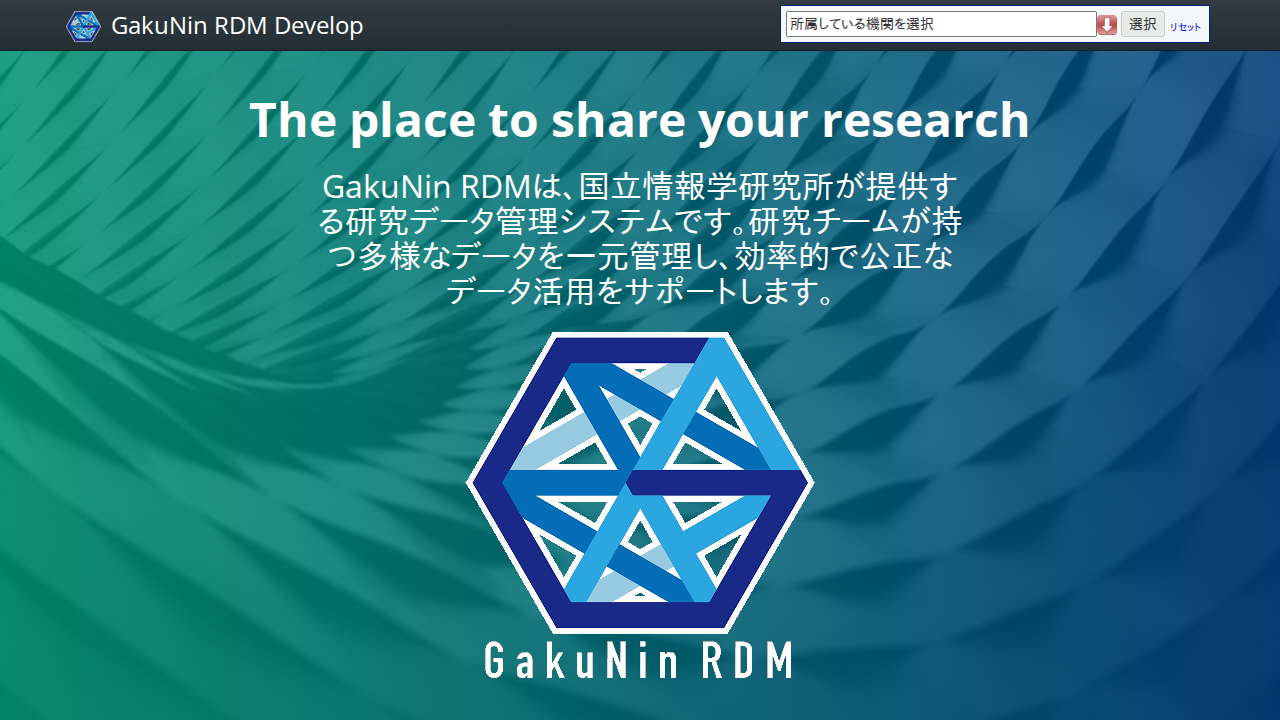

In [5]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await page.goto(rdm_url)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=500)

await run_pw(_step)

## RDMIdPを利用し、既存ユーザー1としてログインする

- GRDM ダッシュボードが表示されること

In [ ]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login(page, idp_name_1, idp_username_admin, idp_password_admin, transition_timeout=transition_timeout)

    # GRDMのボタンが表示されることを確認
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## ダッシュボードから「新規プロジェクト作成」をクリックする
- 「新規プロジェクトの作成」のダイアログが作成されること
## タイトル「TEST-グループ管理連携機能検証-YYYYMMDD(本日の日付)」でプロジェクトを作成する
- ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること

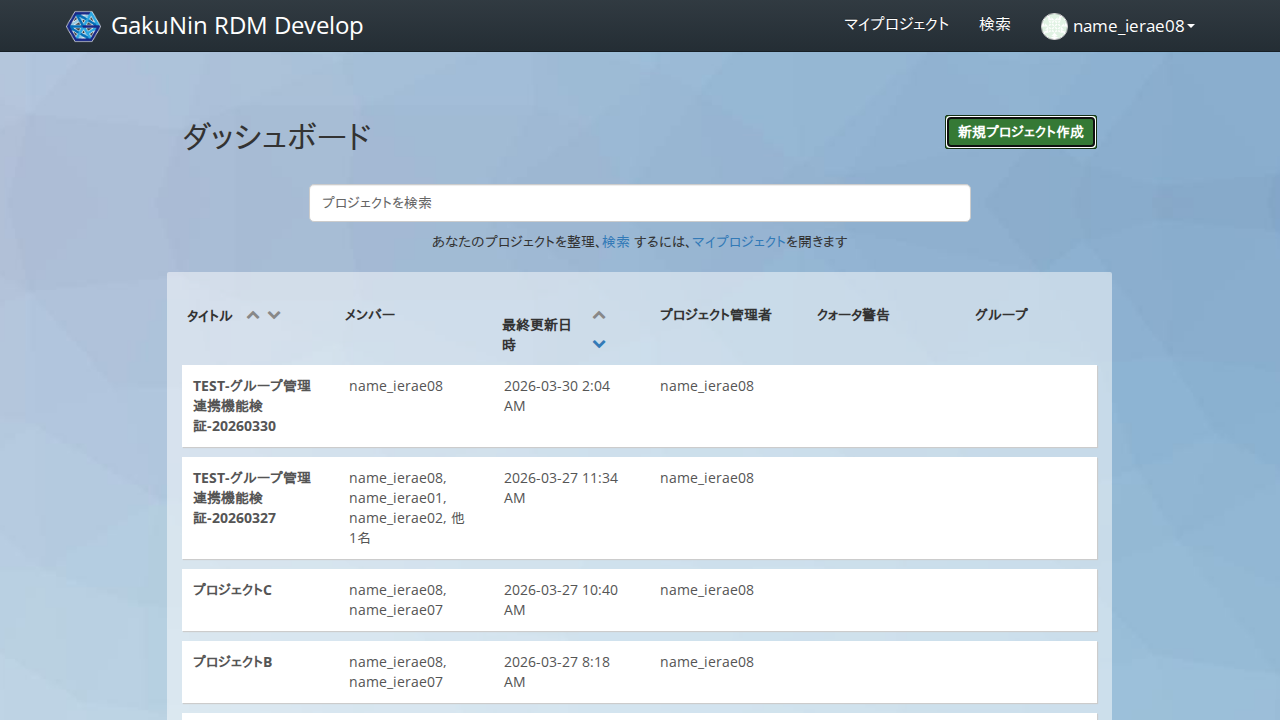

In [7]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name, transition_timeout=transition_timeout)
        
await run_pw(_step)

## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

- 作成したプロジェクトのプロジェクトダッシュボードが表示されること

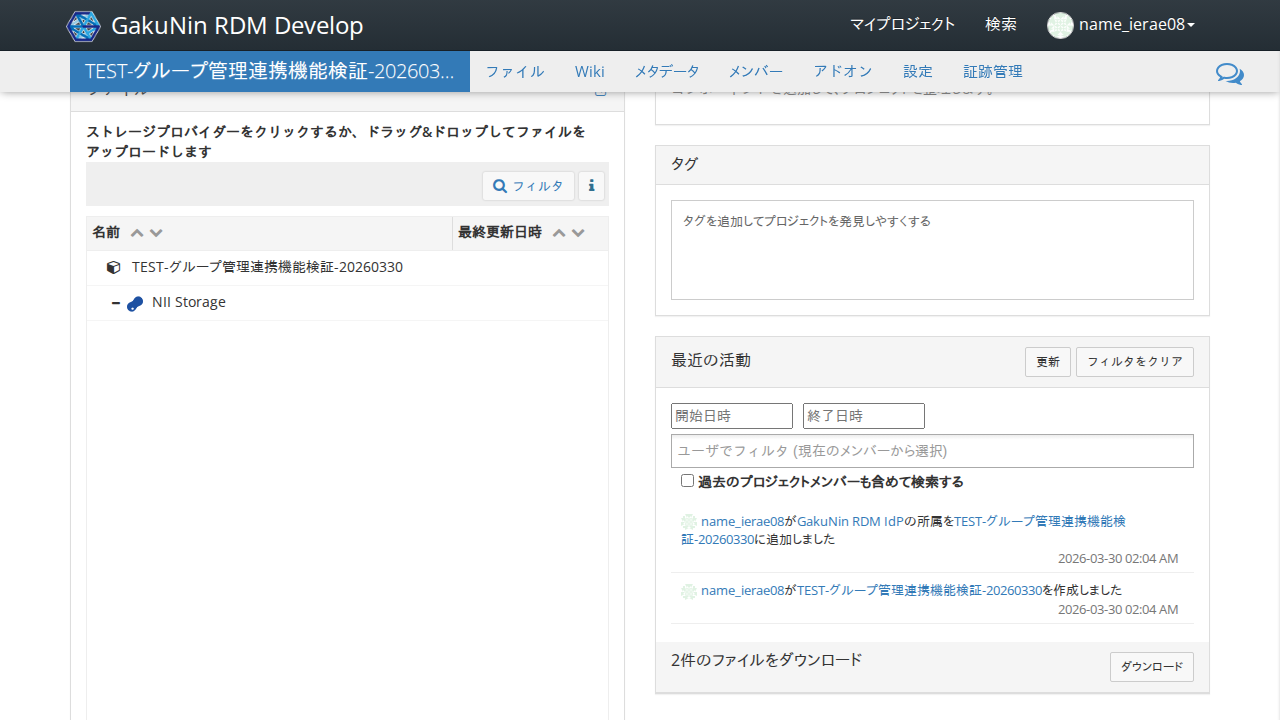

In [8]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_name}"]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

- アドオン設定画面が表示されること

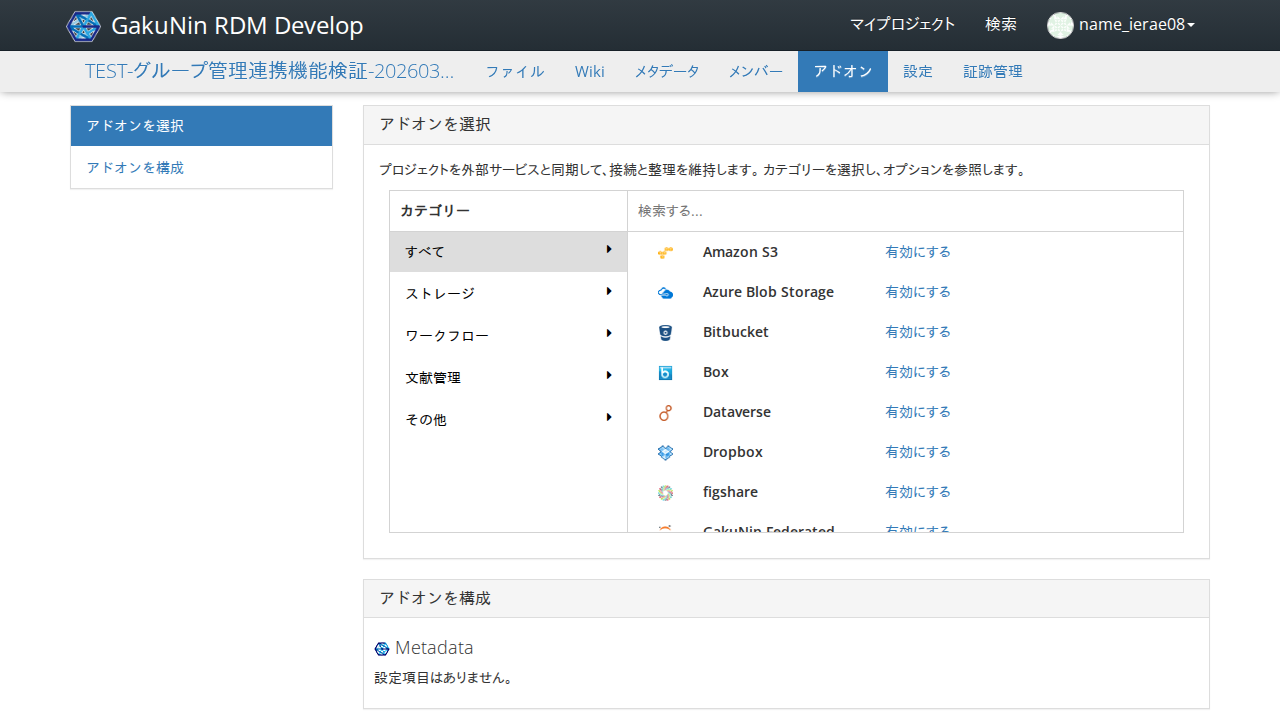

In [9]:
async def _step(page):
    await page.locator("#projectSubnav").get_by_role("link", name="アドオン").click()
    await expect(page.get_by_role("heading", name="アドオンを選択", level=3)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「アドオンを選択」のパネル内「Groups」の行の「有効にする」をクリックする。

・「Groups アドオン規約」のダイアログが表示されること

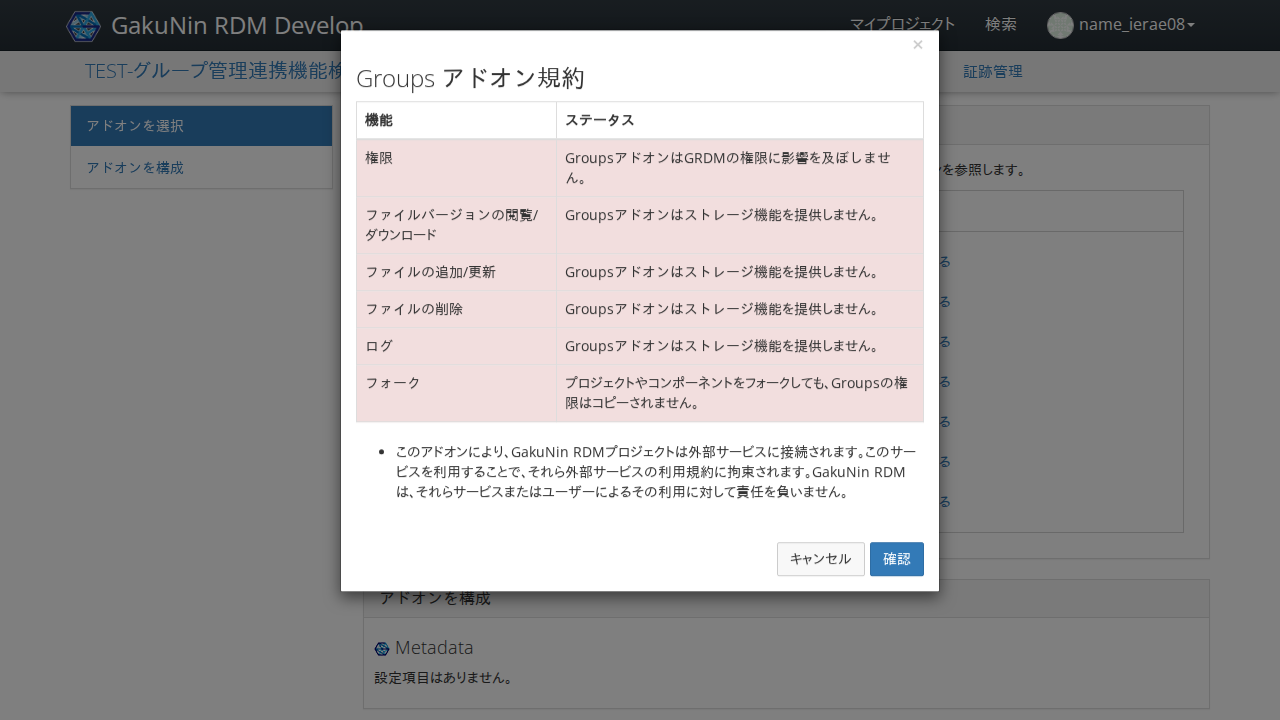

In [10]:
async def _step(page):
    enable_button = page.locator('div.addon-container[name="groups"] a', has_text="有効にする")
    await enable_button.click()
    await expect(page.get_by_role("heading", name="Groups アドオン規約", level=3)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「確認」をクリックする

- 「アドオンを構成」のパネル内に「Groups」の行が追加されること
-  プロジェクトダッシュボードの上部メニューに 「グループ」が追加されること

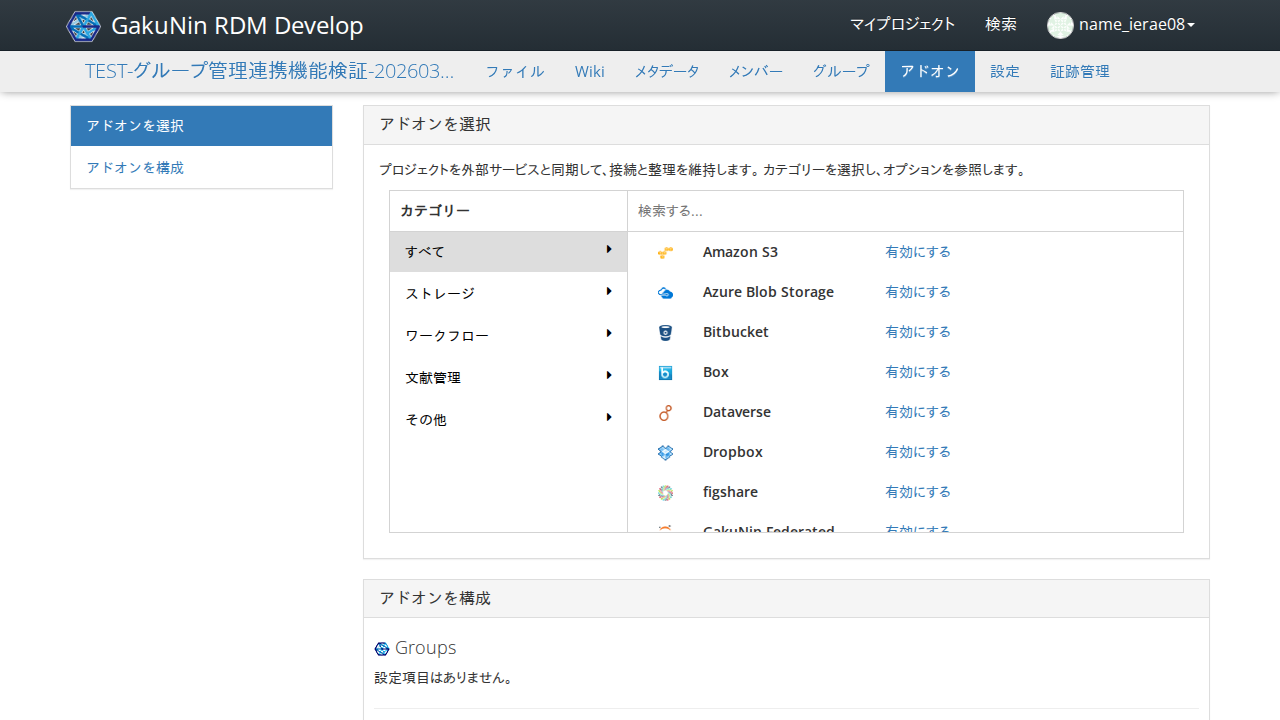

In [11]:
async def _step(page):
    # Locate and click the "確認" button
    confirm_button = page.locator('button[data-bb-handler="confirm"]', has_text="確認")
    await confirm_button.click()
    time.sleep(1)
    await expect(page.locator('div#groupsScope.scripted')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator("#projectSubnav").get_by_role("link", name="グループ", exact=True)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「メンバー」をクリックする

- 「メンバー」画面が表示されること

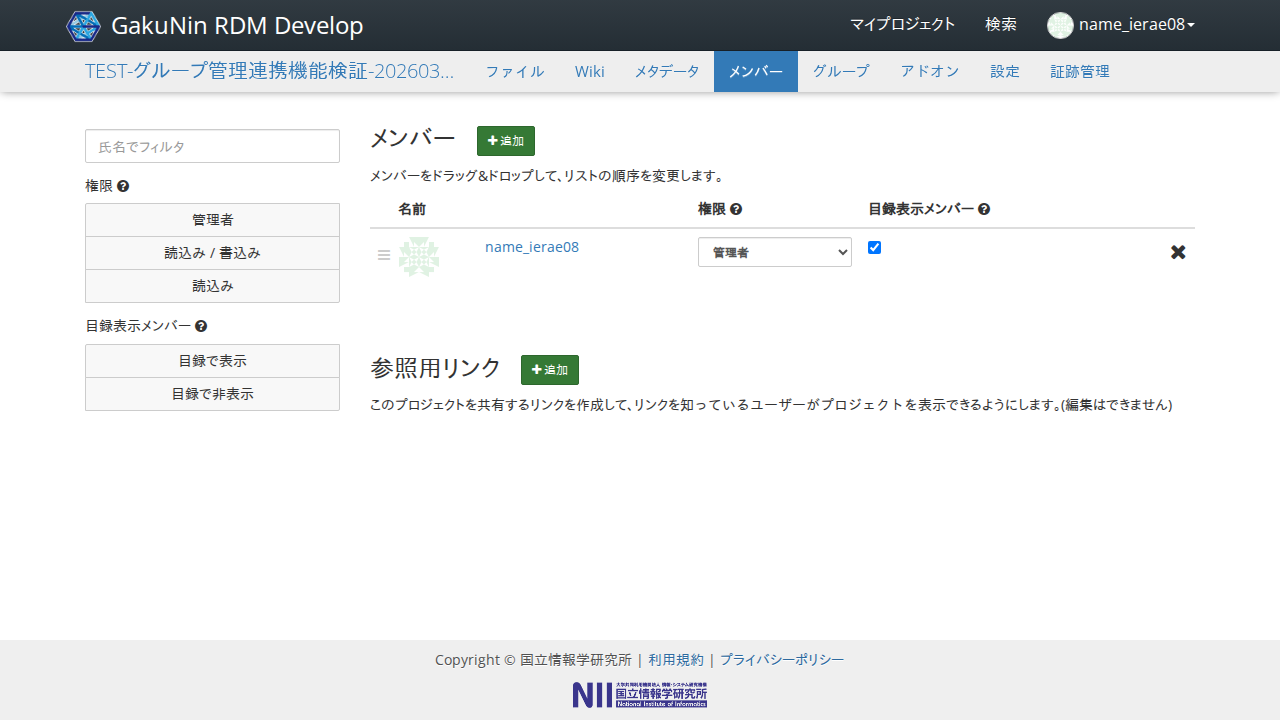

In [12]:
async def _step(page):
    await page.locator("#projectSubnav").get_by_role("link", name="メンバー").click()
    await expect(page.get_by_role("heading", name="メンバー", level=3)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

- アドオン設定画面が表示されること

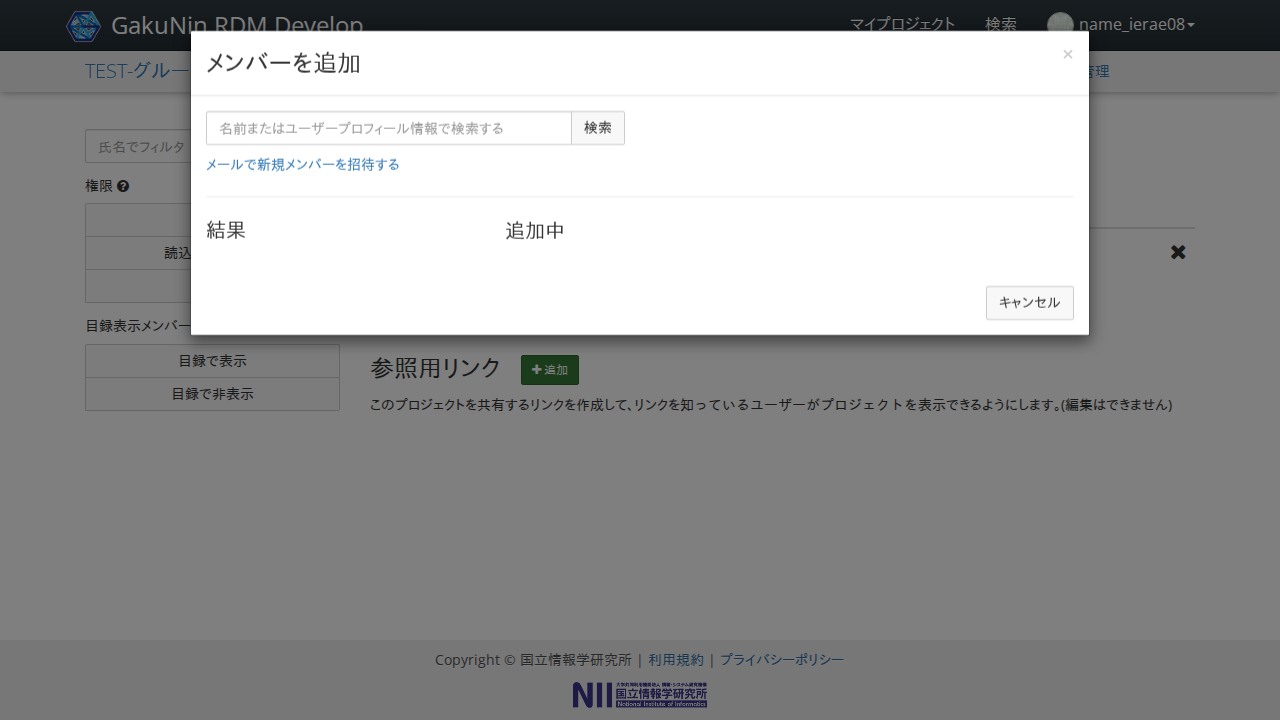

In [13]:
async def _step(page):
    await page.locator('a[href="#addContributors"]').click()
    await expect(page.locator('#addContributors')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#addContributors h3.modal-title')).to_have_text("メンバーを追加", timeout=transition_timeout)

await run_pw(_step)

## 既存ユーザー1の情報(GUID,メールアドレス,名前)を入力して、「検索」ボタンをクリックする

- 「結果」の一覧に既存ユーザー1が表示されること

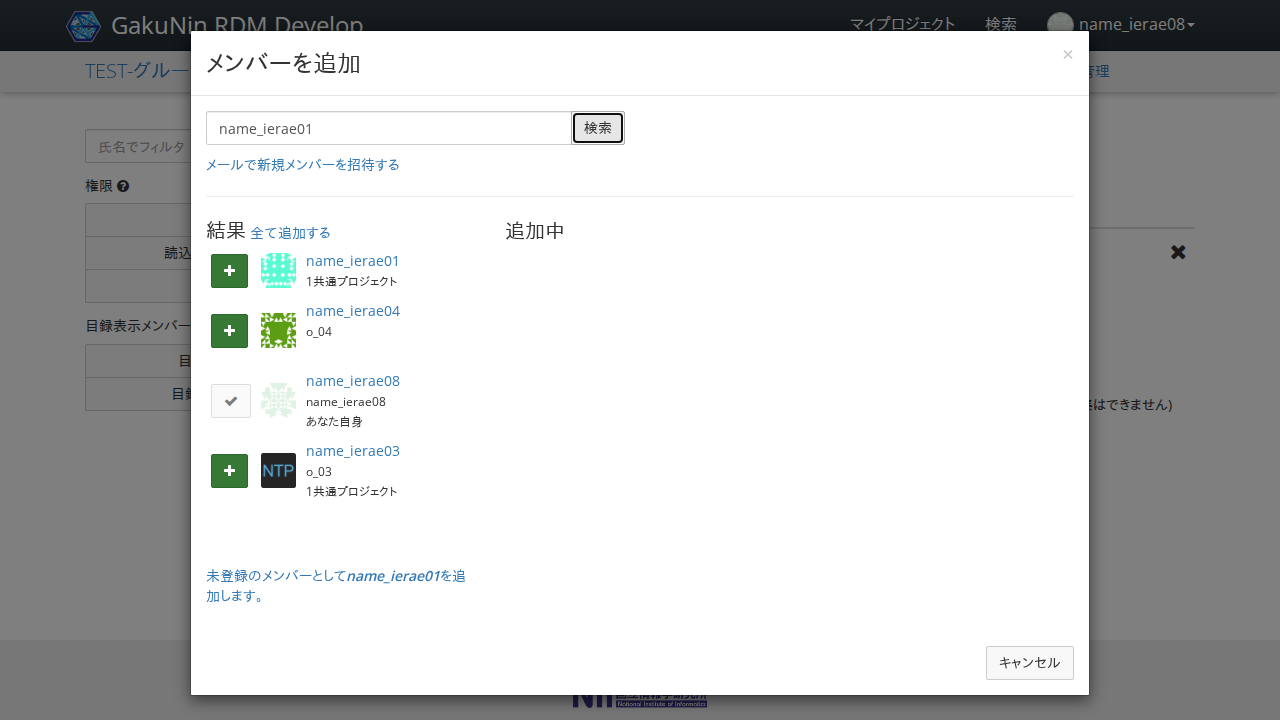

In [ ]:
async def _step(page):
    await page.fill('#addContributors input[data-bind*="value:query"]', user_1)
    await page.click('#addContributors input[type="submit"]')
    row = page.locator('#addContributors tbody tr', has_text=user_1)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="contributor.fullname"]')).to_have_text(user_1, timeout=transition_timeout)

await run_pw(_step)

## 「結果」の一覧の既存ユーザー1の左の「＋」ボタンをクリックする

- 「追加中」の一覧に既存ユーザー1が表示されること

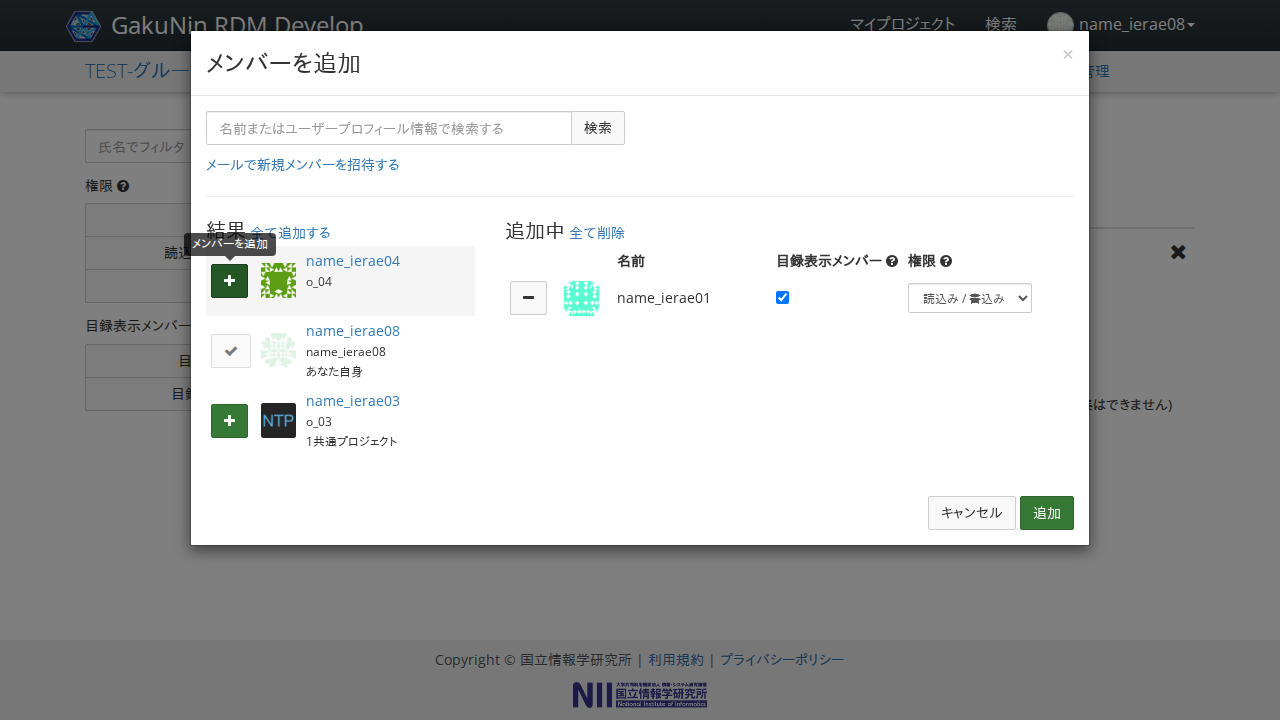

In [15]:
async def _step(page):
    row = page.locator('#addContributors tbody tr', has_text=user_1)
    add_btn = row.locator('a.btn-success.contrib-button.btn-mini')
    await expect(add_btn).to_be_visible(timeout=transition_timeout)
    await add_btn.click()
    modal = page.locator('#addContributors .modal-content')
    await expect(modal).to_be_visible(timeout=transition_timeout)

    # Locate the header span labeled "追加中" (or use "Adding" for English)
    header = modal.locator('span.modal-subheader', has_text='追加中')
    await expect(header).to_be_visible(timeout=transition_timeout)

    await expect(page.locator('#addContributors .modal-body .col-md-8 span', has_text=user_1)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「権限」を「管理者」に設定して、「追加」ボタンをクリックする

- 「メンバー」画面に既存ユーザー1が追加されること

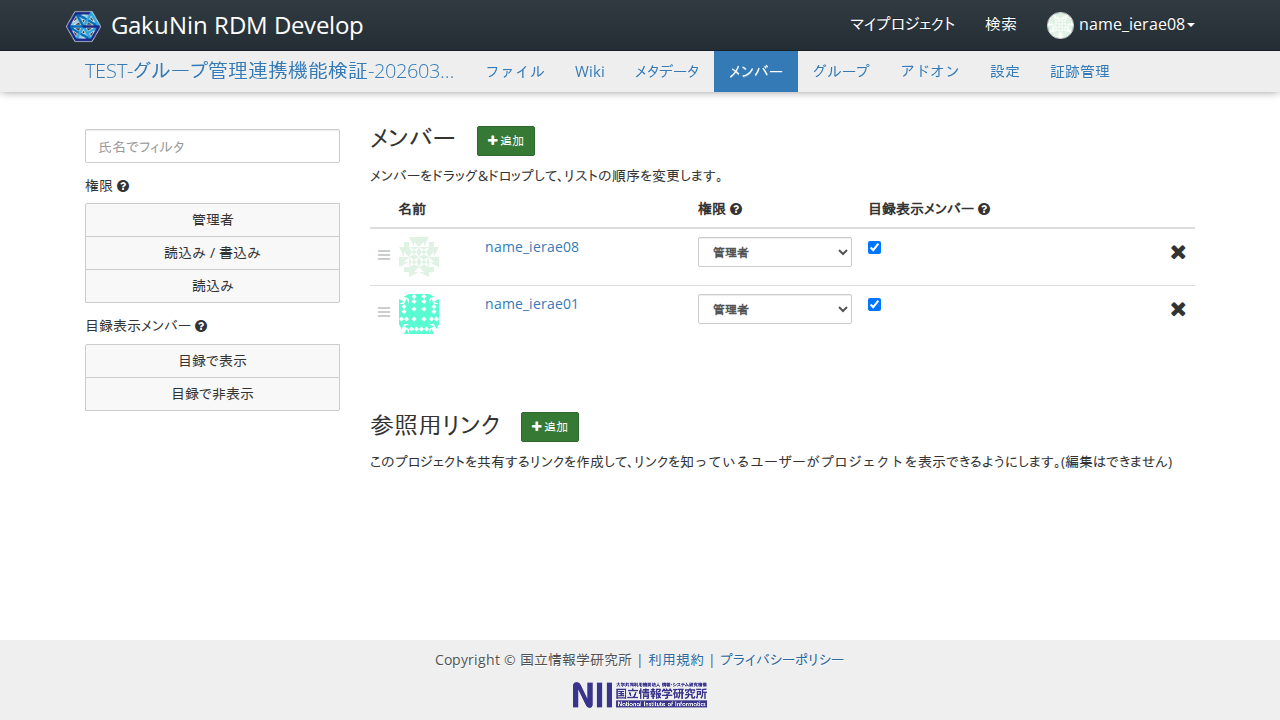

In [16]:
async def _step(page):
    # Locate the selection row on the right (col-md-8) that contains the fullname
    sel_row = page.locator('#addContributors .modal-body .col-md-8 tbody tr', has_text=user_1)
    await expect(sel_row).to_be_visible(timeout=transition_timeout)

    # Locate the permission select inside that row
    permission_select = sel_row.locator('select.form-control.input-sm')

    # Choose the "管理者" option by label (locale-safe)
    await permission_select.select_option(label='管理者')

    # Assert the selected option is the expected label
    await expect(permission_select.locator('option:checked')).to_have_text('管理者', timeout=transition_timeout)
    await page.locator('#addContributors .modal-footer a.btn-success', has_text='追加').click()

    # optional: wait for the modal to close (confirm submit)
    await expect(page.locator('#addContributors')).not_to_be_visible(timeout=transition_timeout)

    member_link = page.get_by_role("link", name=user_1)
    await expect(member_link).to_be_visible(timeout=transition_timeout)
await run_pw(_step)

## 「メンバー」のタイトルの横にある「＋追加」をクリックする

- 「メンバーを追加」ダイアログが表示されること

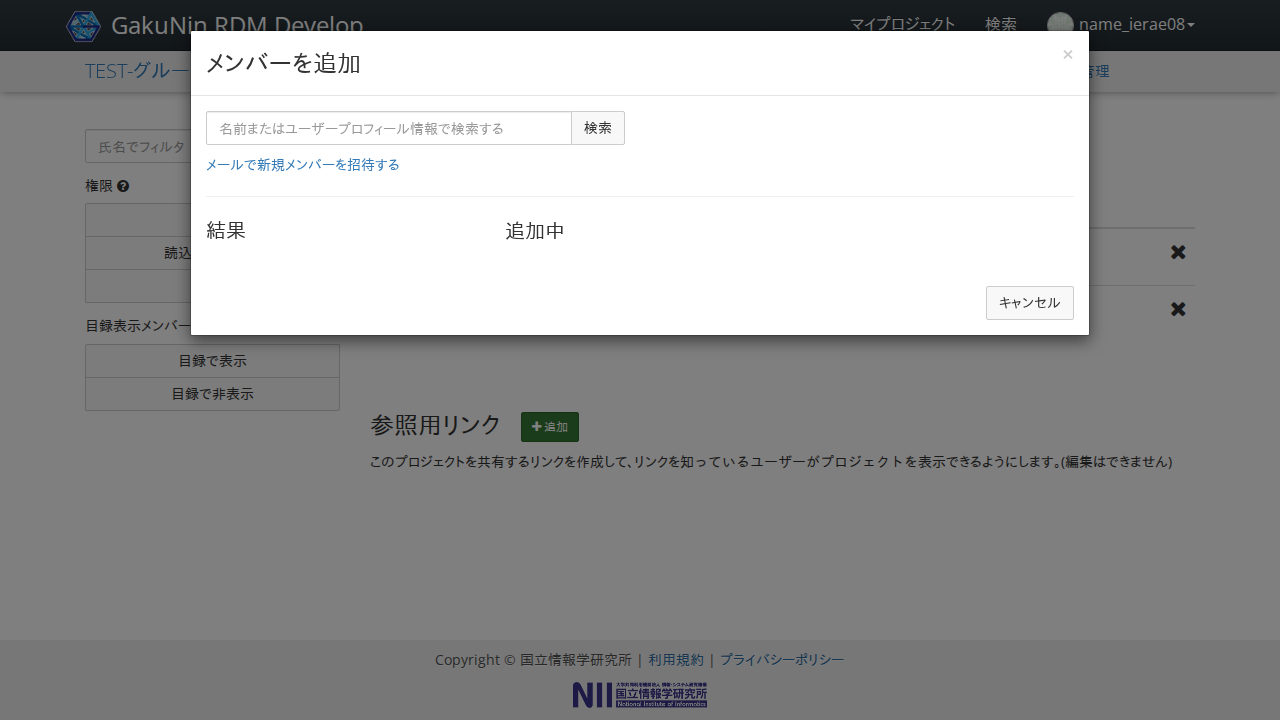

In [17]:
async def _step(page):
    await page.locator('a[href="#addContributors"]').click()
    await expect(page.locator('#addContributors')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#addContributors h3.modal-title')).to_have_text("メンバーを追加", timeout=transition_timeout)

await run_pw(_step)

##  既存ユーザー2の情報(GUID,メールアドレス,名前)を入力して、「検索」ボタンをクリックする

- 「結果」の一覧に既存ユーザー2が表示されること

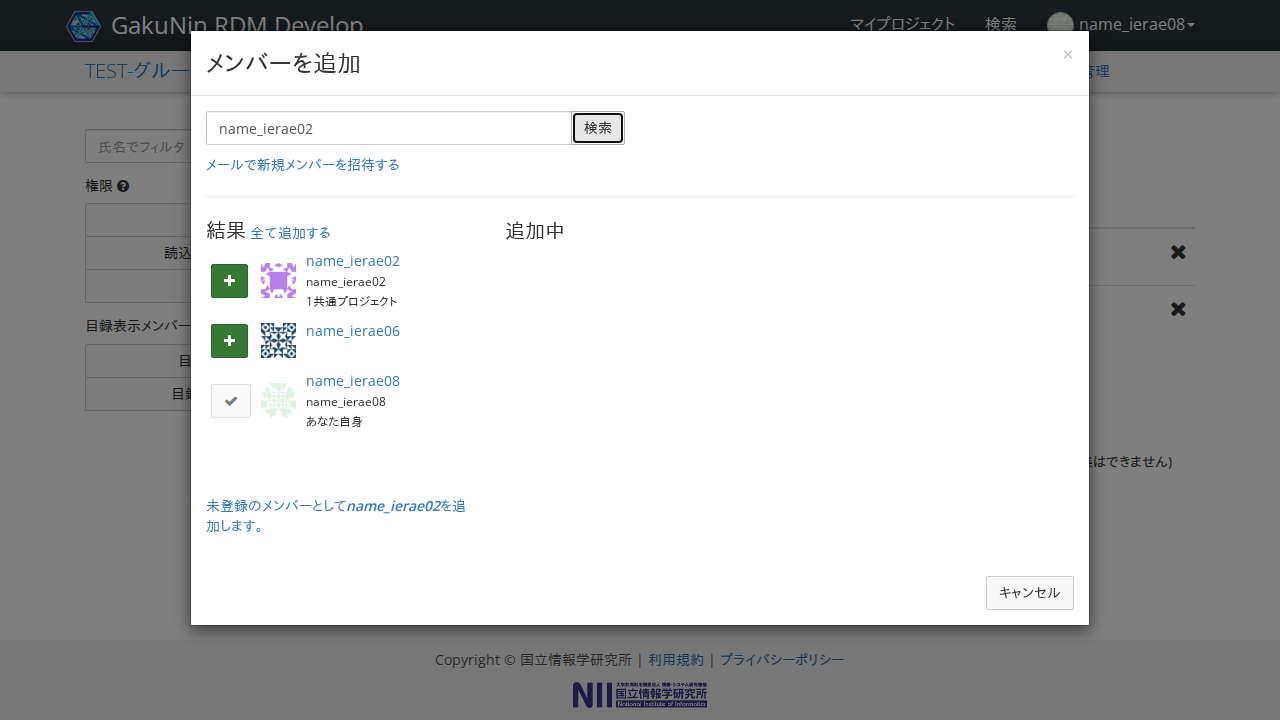

In [ ]:
async def _step(page):
    await page.fill('#addContributors input[data-bind*="value:query"]', user_2)
    await page.click('#addContributors input[type="submit"]')
    row = page.locator('#addContributors tbody tr', has_text=user_2)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="contributor.fullname"]')).to_have_text(user_2, timeout=transition_timeout)

await run_pw(_step)

## 「結果」の一覧の既存ユーザー2の左の「＋」ボタンをクリックする

- 「追加中」の一覧に既存ユーザー2が表示されること

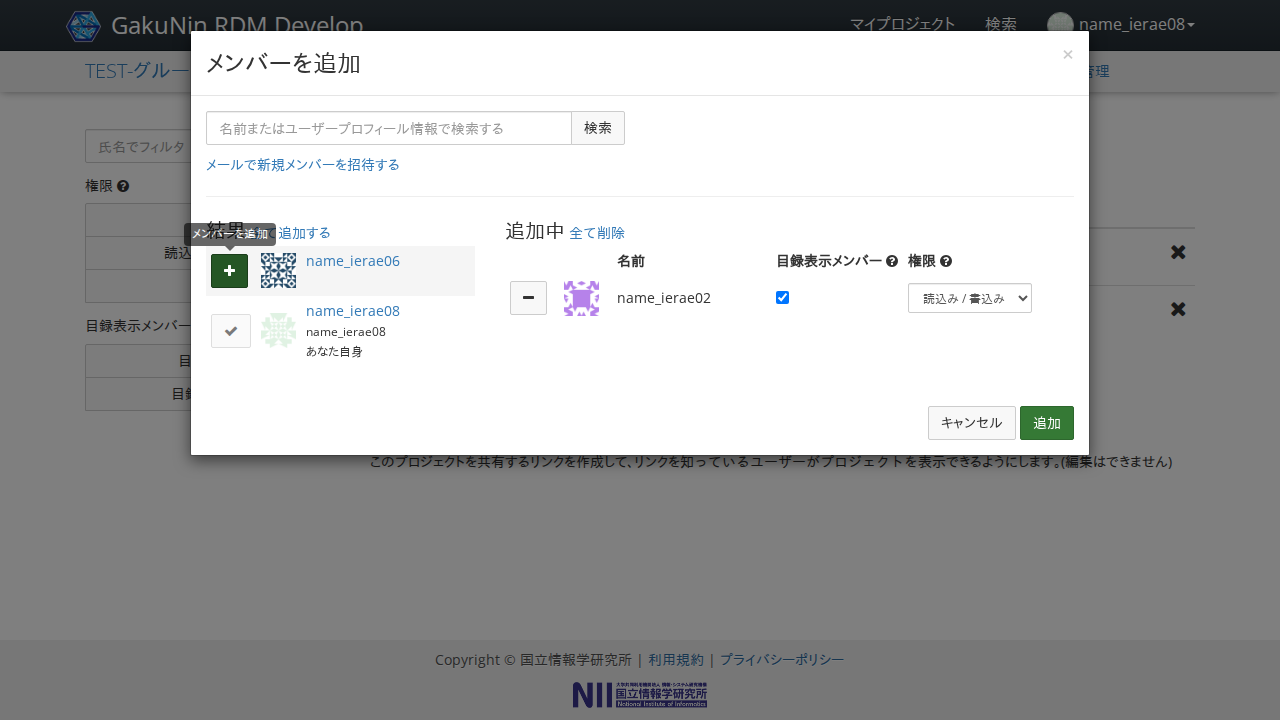

In [19]:
async def _step(page):
    row = page.locator('#addContributors tbody tr', has_text=user_2)
    add_btn = row.locator('a.btn-success.contrib-button.btn-mini')
    await expect(add_btn).to_be_visible(timeout=transition_timeout)
    await add_btn.click()
    modal = page.locator('#addContributors .modal-content')
    await expect(modal).to_be_visible(timeout=transition_timeout)

    # Locate the header span labeled "追加中" (or use "Adding" for English)
    header = modal.locator('span.modal-subheader', has_text='追加中')
    await expect(header).to_be_visible(timeout=transition_timeout)

    await expect(page.locator('#addContributors .modal-body .col-md-8 span', has_text=user_2)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「権限」を「読込み」に設定して、「追加」ボタンをクリックする

- 「メンバー」画面に既存ユーザー2が追加されること

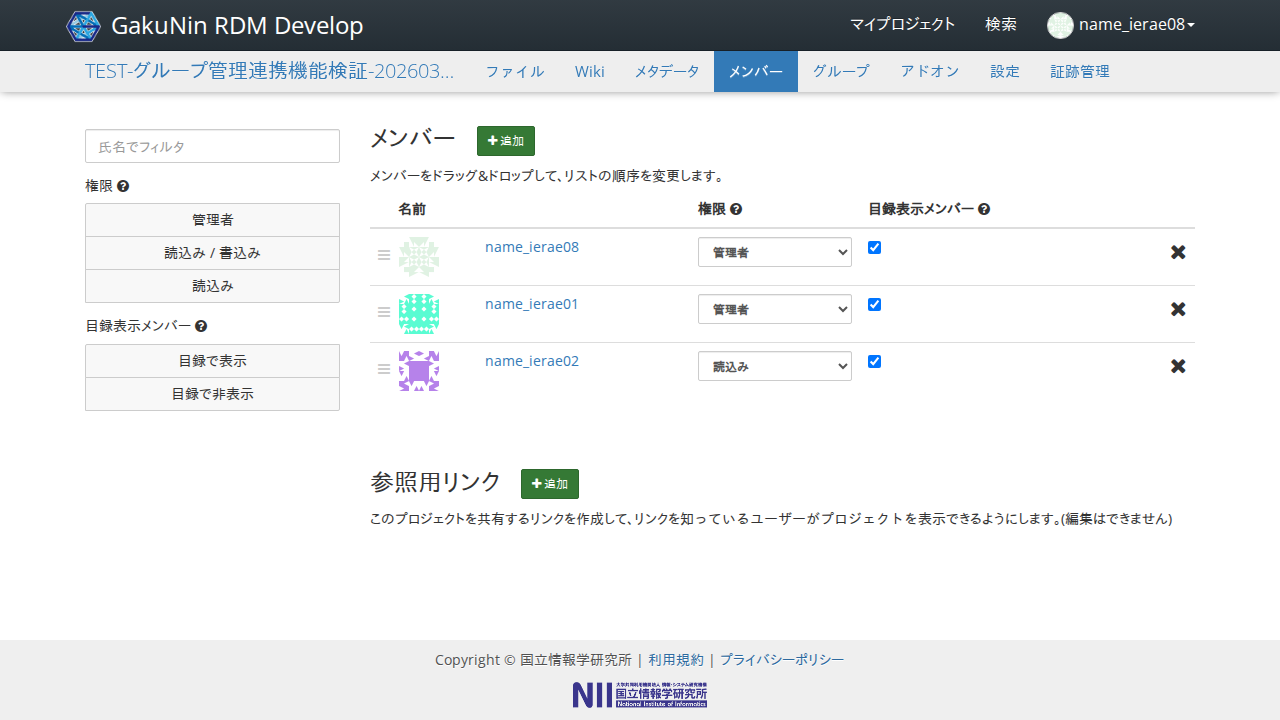

In [20]:
async def _step(page):
    # Locate the selection row on the right (col-md-8) that contains the fullname
    sel_row = page.locator('#addContributors .modal-body .col-md-8 tbody tr', has_text=user_2)
    await expect(sel_row).to_be_visible(timeout=transition_timeout)

    # Locate the permission select inside that row
    permission_select = sel_row.locator('select.form-control.input-sm')

    # Choose the "読込み" option by label (locale-safe)
    await permission_select.select_option(label='読込み')

    # Assert the selected option is the expected label
    await expect(permission_select.locator('option:checked')).to_have_text('読込み', timeout=transition_timeout)
    await page.locator('#addContributors .modal-footer a.btn-success', has_text='追加').click()

    # optional: wait for the modal to close (confirm submit)
    await expect(page.locator('#addContributors')).not_to_be_visible(timeout=transition_timeout)

    member_link = page.get_by_role("link", name=user_2)
    await expect(member_link).to_be_visible(timeout=transition_timeout)
await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「メンバー」をクリックする

「メンバー」画面が表示されること

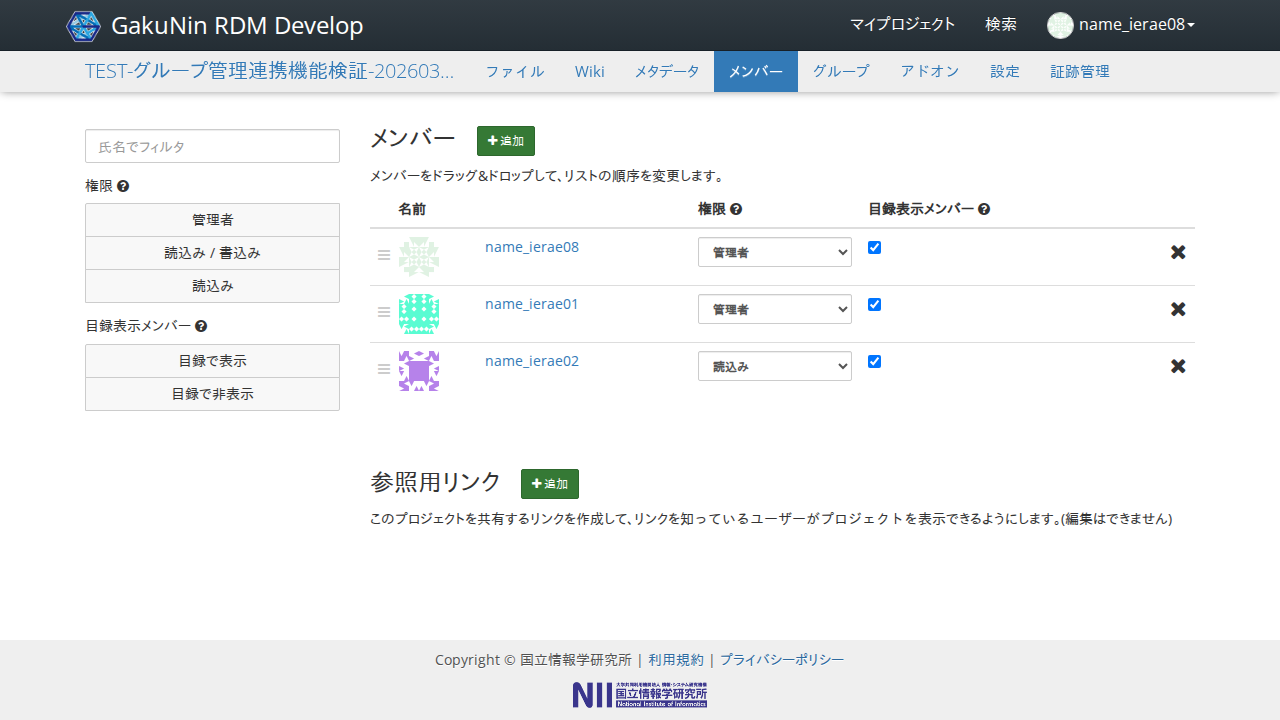

In [21]:
async def _step(page):
    await page.locator("#projectSubnav").get_by_role("link", name="メンバー").click()
    await expect(page.get_by_role("heading", name="メンバー", level=3)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「メンバー」のタイトルの横にある「＋追加」をクリックする

「メンバーを追加」ダイアログが表示されること

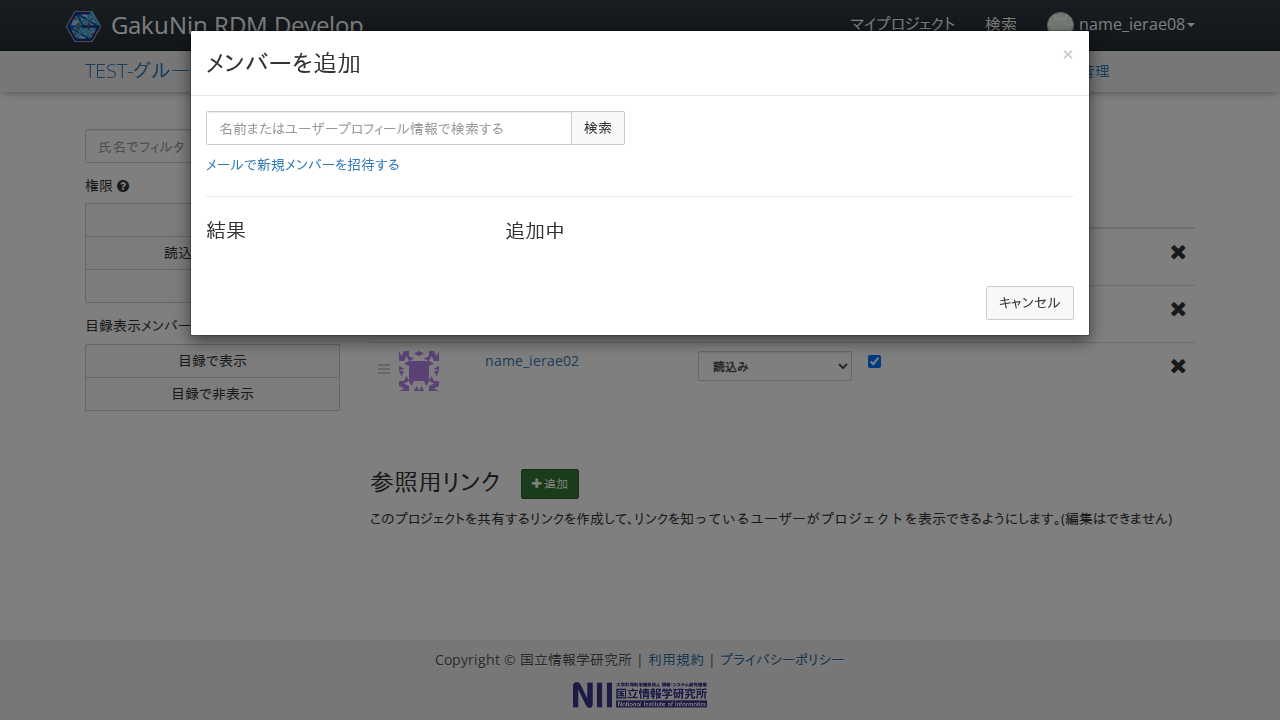

In [22]:
async def _step(page):
    await page.locator('a[href="#addContributors"]').click()
    await expect(page.locator('#addContributors')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#addContributors h3.modal-title')).to_have_text("メンバーを追加", timeout=transition_timeout)

await run_pw(_step)

## 既存ユーザー3の情報(GUID,メールアドレス,名前)を入力して、「検索」ボタンをクリックする

「結果」の一覧に既存ユーザー3が表示されること

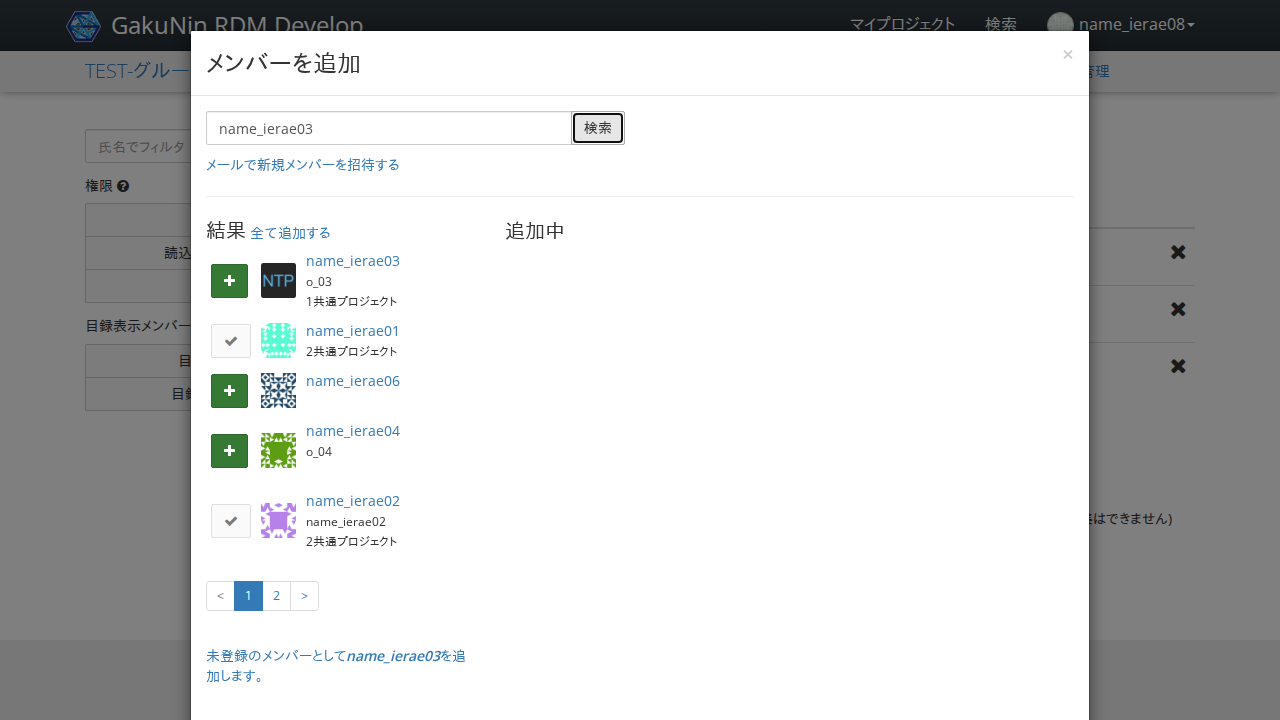

In [ ]:
async def _step(page):
    await page.fill('#addContributors input[data-bind*="value:query"]', user_3)
    await page.click('#addContributors input[type="submit"]')
    row = page.locator('#addContributors tbody tr', has_text=user_3)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="contributor.fullname"]')).to_have_text(user_3, timeout=transition_timeout)

await run_pw(_step)

## 「結果」の一覧の既存ユーザー3の左の「＋」ボタンをクリックする

「追加中」の一覧に既存ユーザー3が表示されること

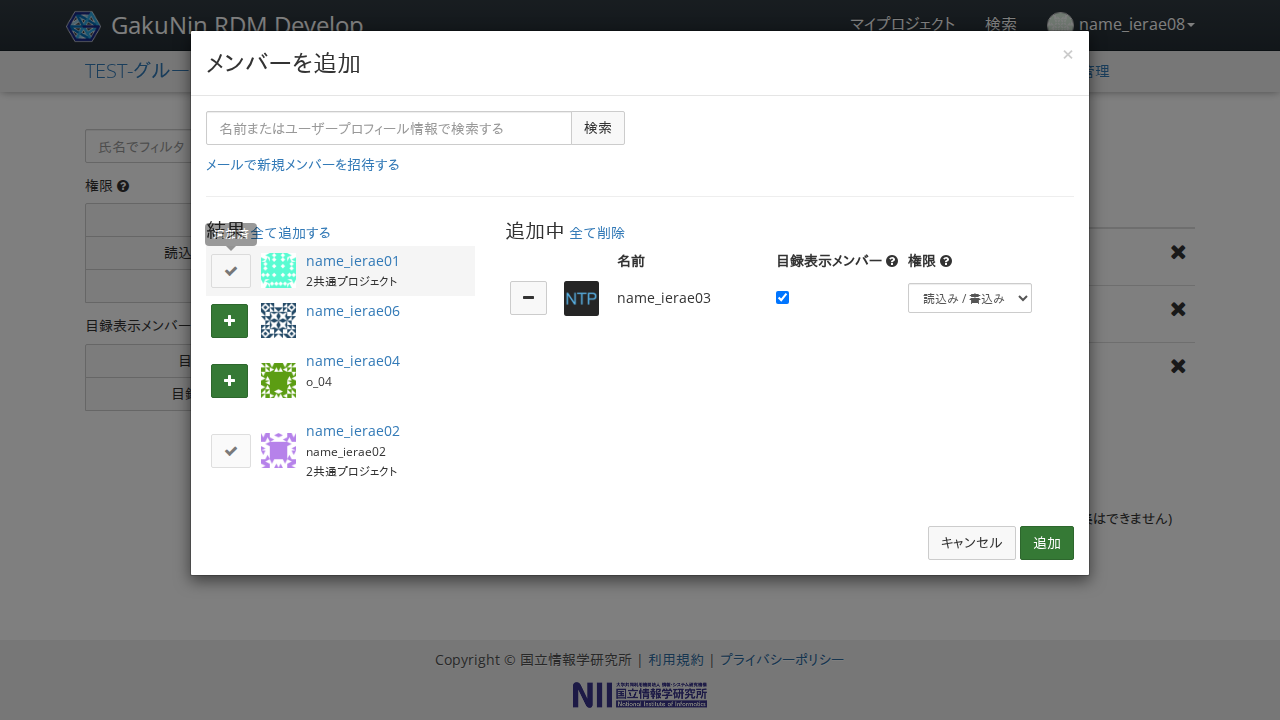

In [24]:
async def _step(page):
    row = page.locator('#addContributors tbody tr', has_text=user_3)
    add_btn = row.locator('a.btn-success.contrib-button.btn-mini')
    await expect(add_btn).to_be_visible(timeout=transition_timeout)
    await add_btn.click()
    modal = page.locator('#addContributors .modal-content')
    await expect(modal).to_be_visible(timeout=transition_timeout)

    # Locate the header span labeled "追加中" (or use "Adding" for English)
    header = modal.locator('span.modal-subheader', has_text='追加中')
    await expect(header).to_be_visible(timeout=transition_timeout)

    await expect(
        page.locator('#addContributors .modal-body .col-md-8 span', has_text=user_3)
    ).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「権限」を「読込み/書込み」に設定して、「追加」ボタンをクリックする

「メンバー」画面に既存ユーザー3が追加されること

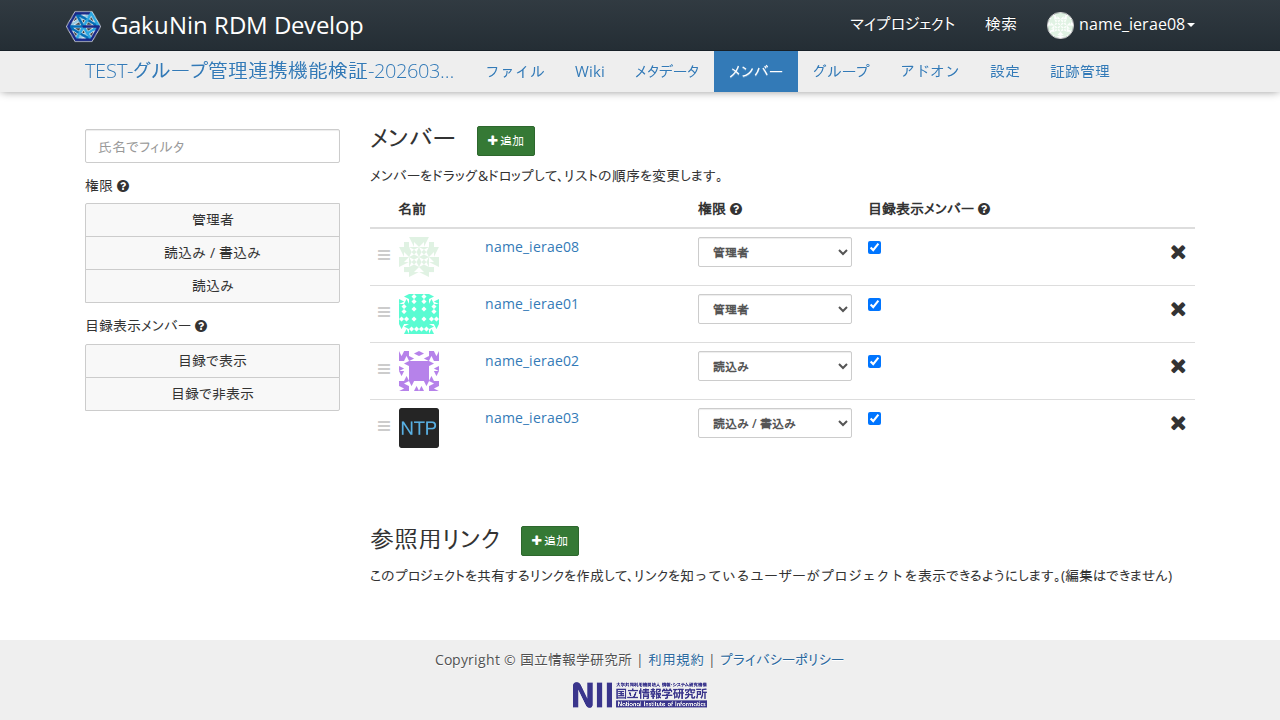

In [25]:
async def _step(page):
    # Locate the selection row on the right (col-md-8) that contains the fullname
    sel_row = page.locator('#addContributors .modal-body .col-md-8 tbody tr', has_text=user_3)
    await expect(sel_row).to_be_visible(timeout=transition_timeout)

    # Locate the permission select inside that row
    permission_select = sel_row.locator('select.form-control.input-sm')

    # Choose the "読込み / 書込み" option by label (locale-safe)
    await permission_select.select_option(label='読込み / 書込み')

    # Assert the selected option is the expected label
    await expect(permission_select.locator('option:checked')).to_have_text('読込み / 書込み', timeout=transition_timeout)
    await page.locator('#addContributors .modal-footer a.btn-success', has_text='追加').click()

    # optional: wait for the modal to close (confirm submit)
    await expect(page.locator('#addContributors')).not_to_be_visible(timeout=transition_timeout)
    member_link = page.get_by_role("link", name=user_3)
    await expect(member_link).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「グループ」をクリックする

「グループ」画面が表示されること

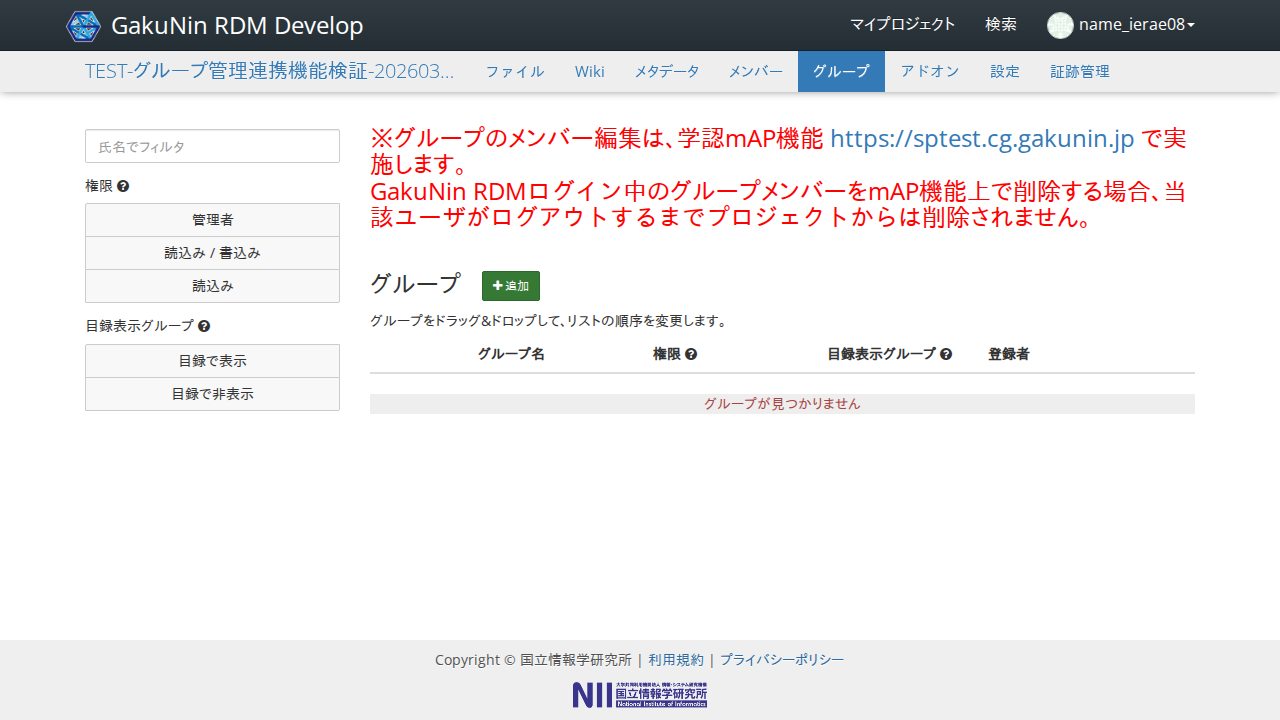

In [ ]:
async def _step(page):
    await page.locator("#projectSubnav").get_by_role("link", name="グループ", exact=True).click()
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「グループ」のタイトルの横にある「＋追加」をクリックする

- 「グループを追加」ダイアログが表示されること

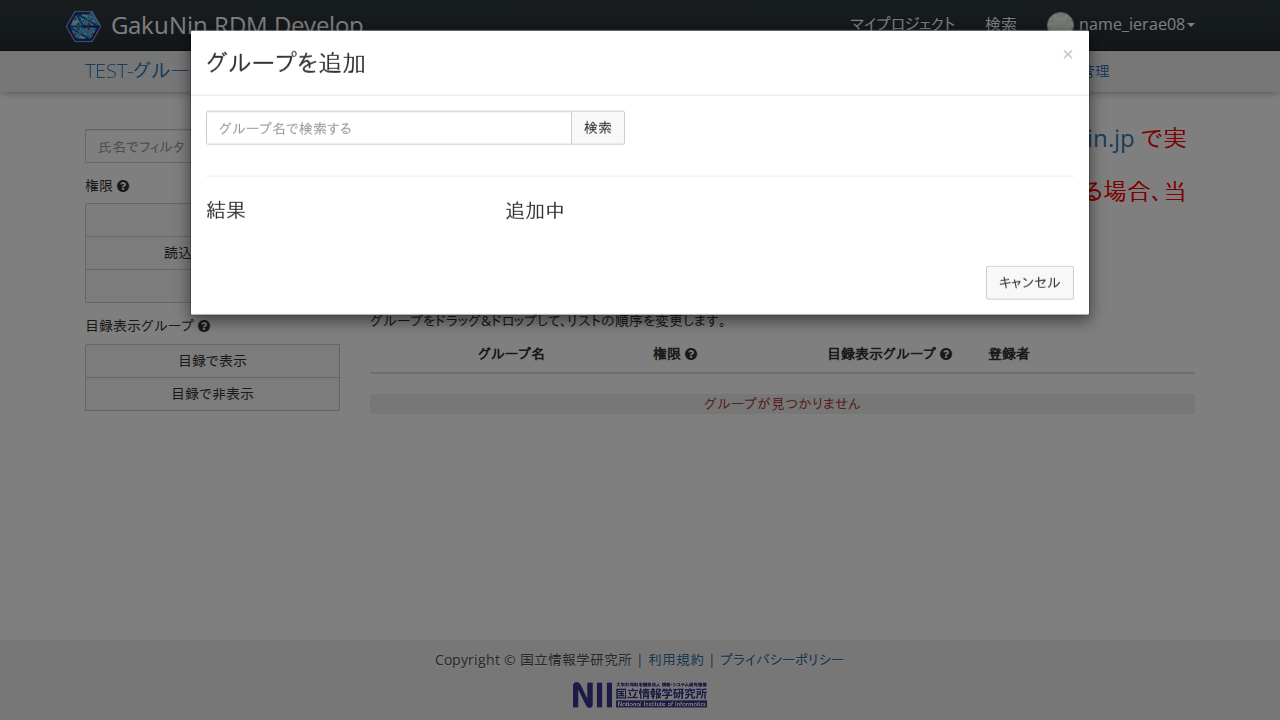

In [27]:
async def _step(page):
    await page.locator('a[href="#addGroups"]').click()
    await expect(page.locator('#addGroups')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#addGroups h3.modal-title')).to_have_text("グループを追加", timeout=transition_timeout)

await run_pw(_step)

## 既存ユーザー2が所属するグループ(グループA)を入力して、「検索」ボタンをクリックする

- 「結果」の一覧に既存ユーザー2が所属するグループ(グループA)が表示されること
- 「結果」の一覧に既存ユーザー3が所属するグループ(グループB)が表示されること
- 「結果」の一覧に既存ユーザー4が所属するグループ(グループC)が表示されること
- 「結果」の一覧に既存ユーザー5が所属するグループ(グループD)が表示されること

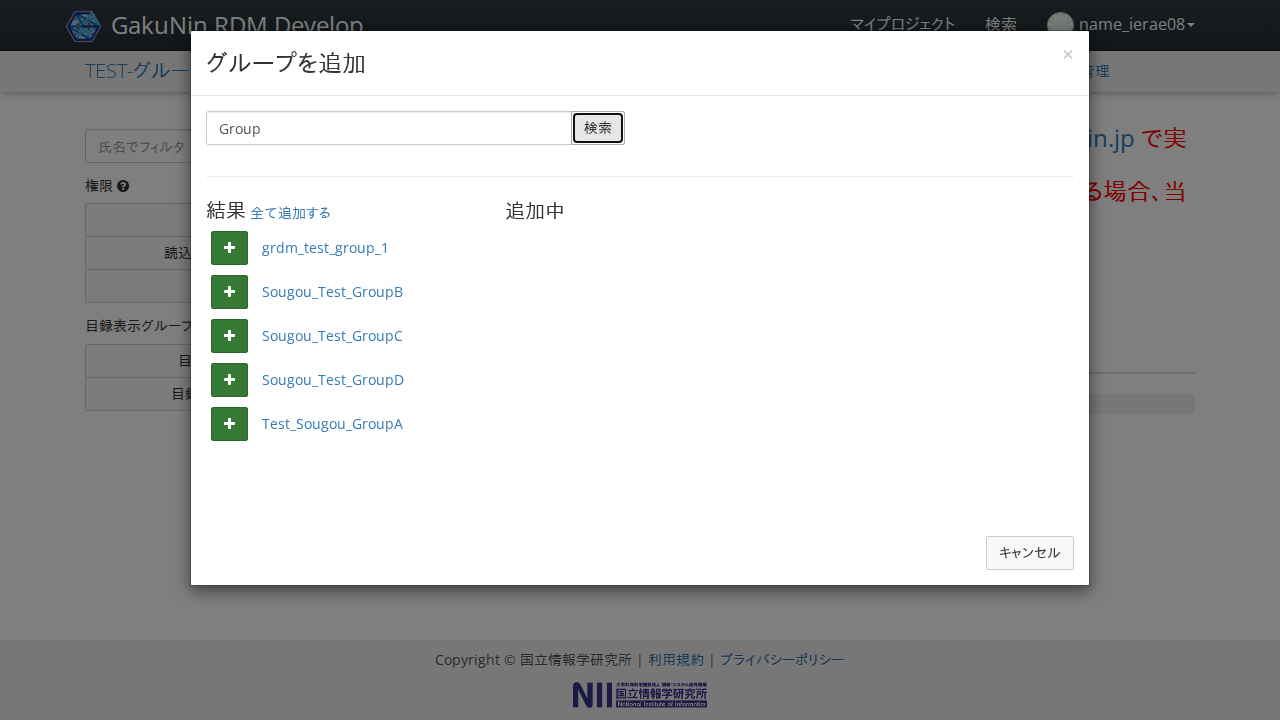

In [ ]:
async def _step(page):
    await page.fill('#addGroups input[data-bind*="value:query"]', group_query)
    await page.click('#addGroups input[type="submit"]')

    # Group A 
    row = page.locator('#addGroups tbody tr', has_text=group_a)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_a, timeout=transition_timeout)

    # Group B
    row = page.locator('#addGroups tbody tr', has_text=group_b)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_b, timeout=transition_timeout)

    # Group C
    row = page.locator('#addGroups tbody tr', has_text=group_c)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_c, timeout=transition_timeout)

    # Group D
    row = page.locator('#addGroups tbody tr', has_text=group_d)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_d, timeout=transition_timeout)

await run_pw(_step)

## 「結果」の一覧の既存ユーザー2が所属するグループ(グループA)の横の「＋」ボタンをクリックする

- 「追加中」の一覧に既存ユーザー2が所属するグループ(グループA)が表示されること

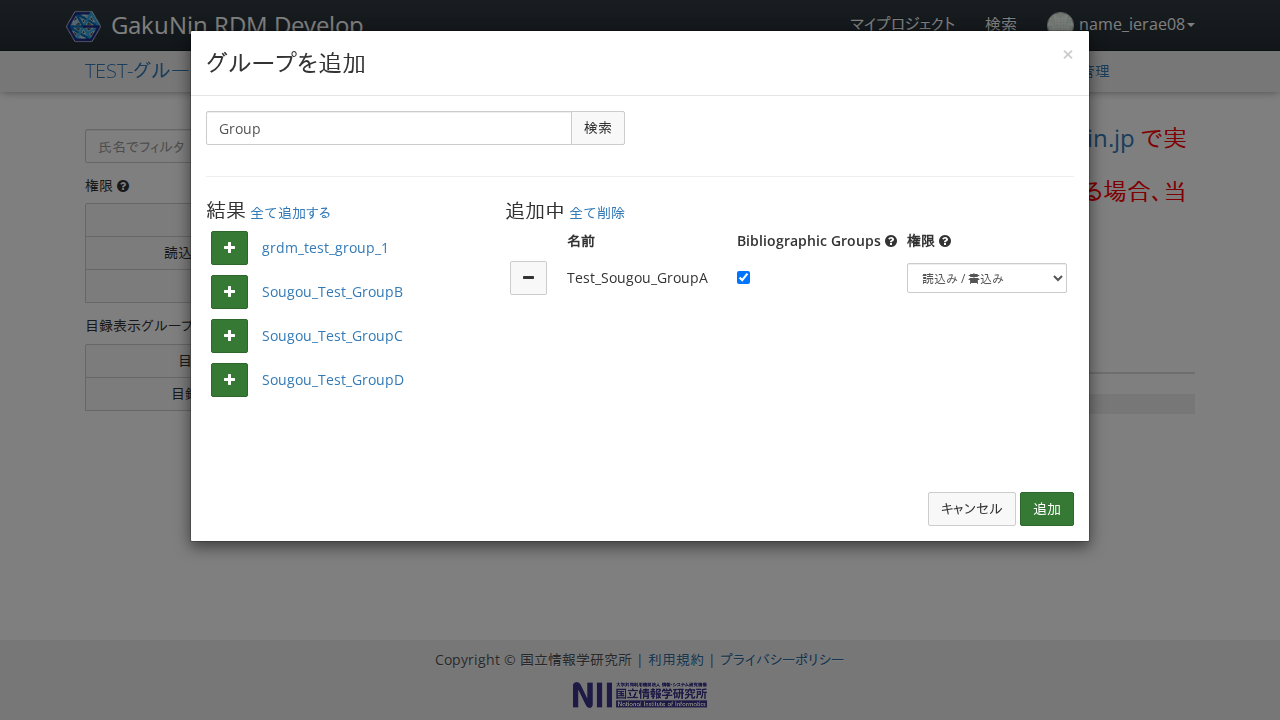

In [29]:
async def _step(page):
    row = page.locator('#addGroups tbody tr', has_text=group_a)
    add_btn = row.locator('a.btn-success.contrib-button.btn-mini')
    await expect(add_btn).to_be_visible(timeout=transition_timeout)
    await add_btn.click()
    modal = page.locator('#addGroups .modal-content')
    await expect(modal).to_be_visible(timeout=transition_timeout)

    # Locate the header span labeled "追加中" (or use "Adding" for English)
    header = modal.locator('span.modal-subheader', has_text='追加中')
    await expect(header).to_be_visible(timeout=transition_timeout)

    await expect(
        page.locator('#addGroups .modal-body .col-md-8 span', has_text=group_a)
    ).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「権限」を「読込み」に設定して、「追加」ボタンをクリックする

- 「グループ」画面に既存ユーザー2が所属するグループ(グループA)が追加されること
- 「グループ」画面に既存ユーザー2が所属するグループ(グループA)の「権限」が「読込み/書込み」に設定されていること


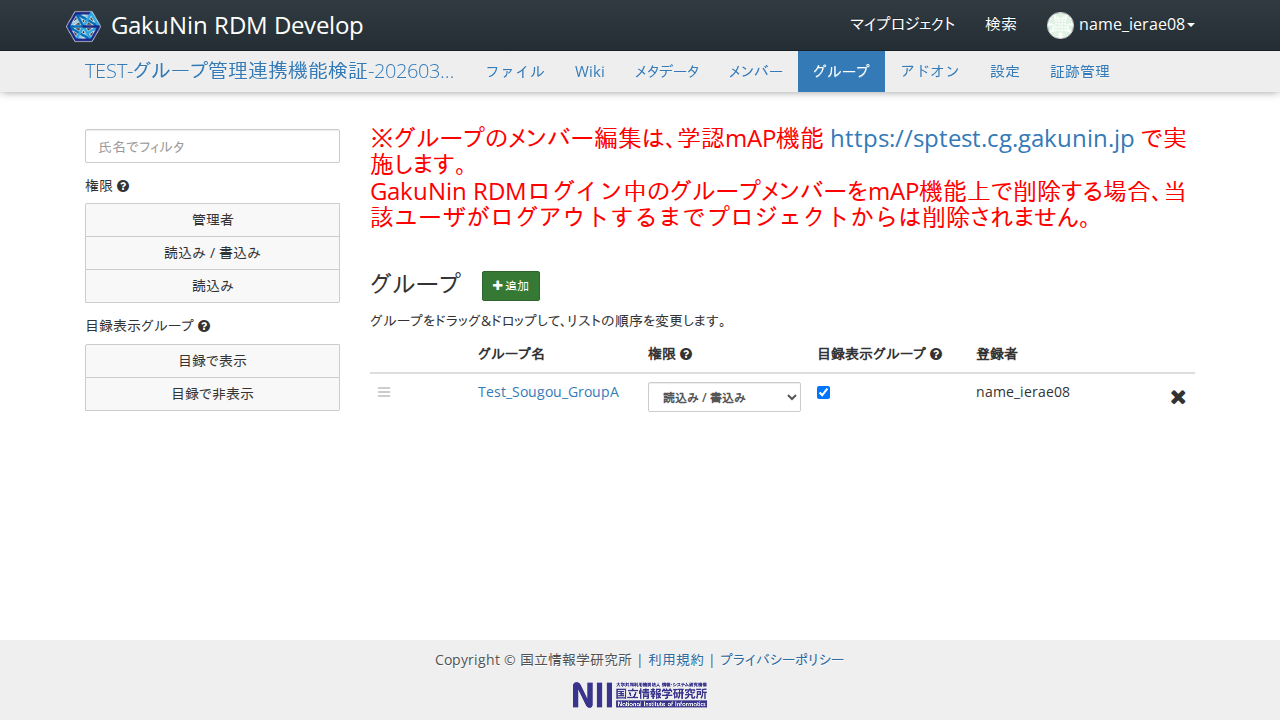

In [30]:
async def _step(page):
    # Locate the selection row on the right (col-md-8) that contains the fullname
    sel_row = page.locator('#addGroups .modal-body .col-md-8 tbody tr', has_text=group_a)
    await expect(sel_row).to_be_visible(timeout=transition_timeout)

    # Locate the permission select inside that row
    permission_select = sel_row.locator('select.form-control.input-sm')

    # Choose the "読込み" option by label (locale-safe)
    await permission_select.select_option(label='読込み / 書込み')

    # Assert the selected option is the expected label
    await expect(permission_select.locator('option:checked')).to_have_text('読込み / 書込み', timeout=transition_timeout)
    await page.locator('#addGroups .modal-footer a.btn-success', has_text='追加').click()

    # optional: wait for the modal to close (confirm submit)
    await expect(page.locator('#addGroups')).not_to_be_visible(timeout=transition_timeout)

    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_a)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)
await run_pw(_step)

## 「グループ」のタイトルの横にある「＋追加」をクリックする

- 「グループを追加」ダイアログが表示されること

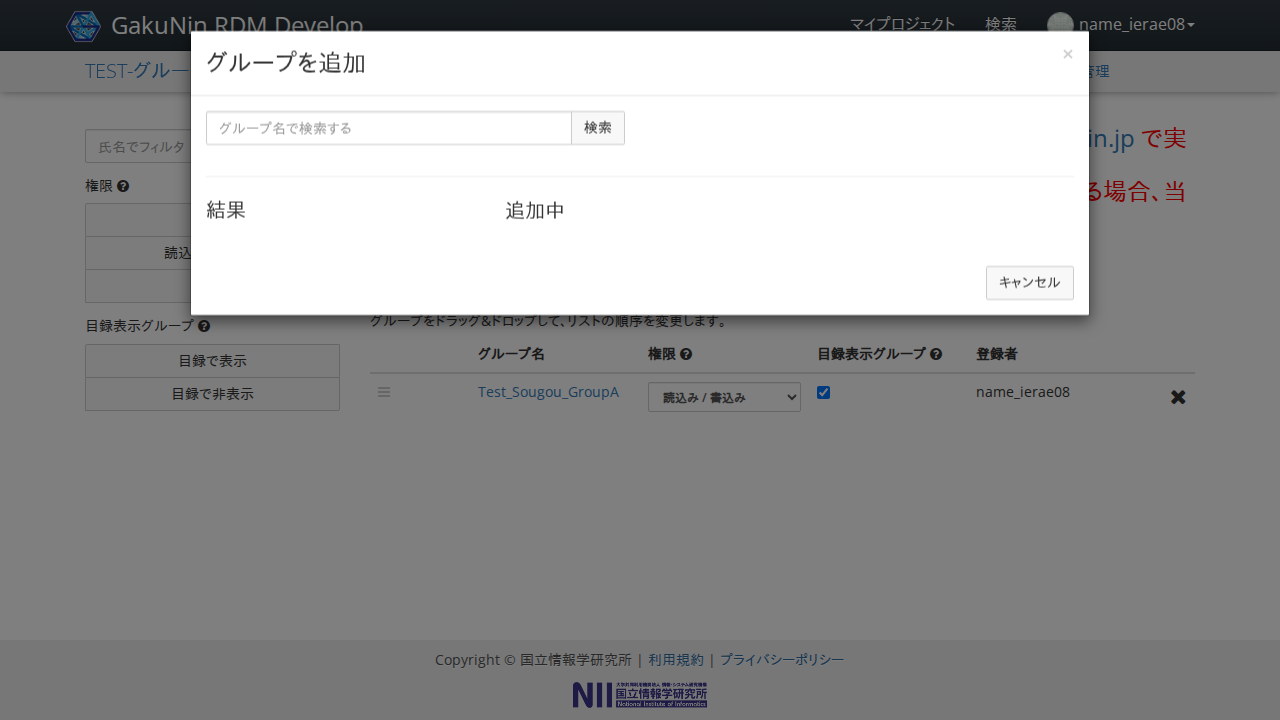

In [31]:
async def _step(page):
    await page.locator('a[href="#addGroups"]').click()
    await expect(page.locator('#addGroups')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#addGroups h3.modal-title')).to_have_text("グループを追加", timeout=transition_timeout)

await run_pw(_step)

##  既存ユーザー3が所属するグループ(グループB)を入力して、「検索」ボタンをクリックする

- 「結果」の一覧に既存ユーザー2が所属するグループ(グループA)が表示されること
- 「結果」の一覧に既存ユーザー3が所属するグループ(グループB)が表示されること
- 「結果」の一覧に既存ユーザー4が所属するグループ(グループC)が表示されること
- 「結果」の一覧に既存ユーザー5が所属するグループ(グループD)が表示されること
- 「結果」の一覧に既存ユーザー2が所属するグループ(グループA)が「✔️(追加済)」として表示されること

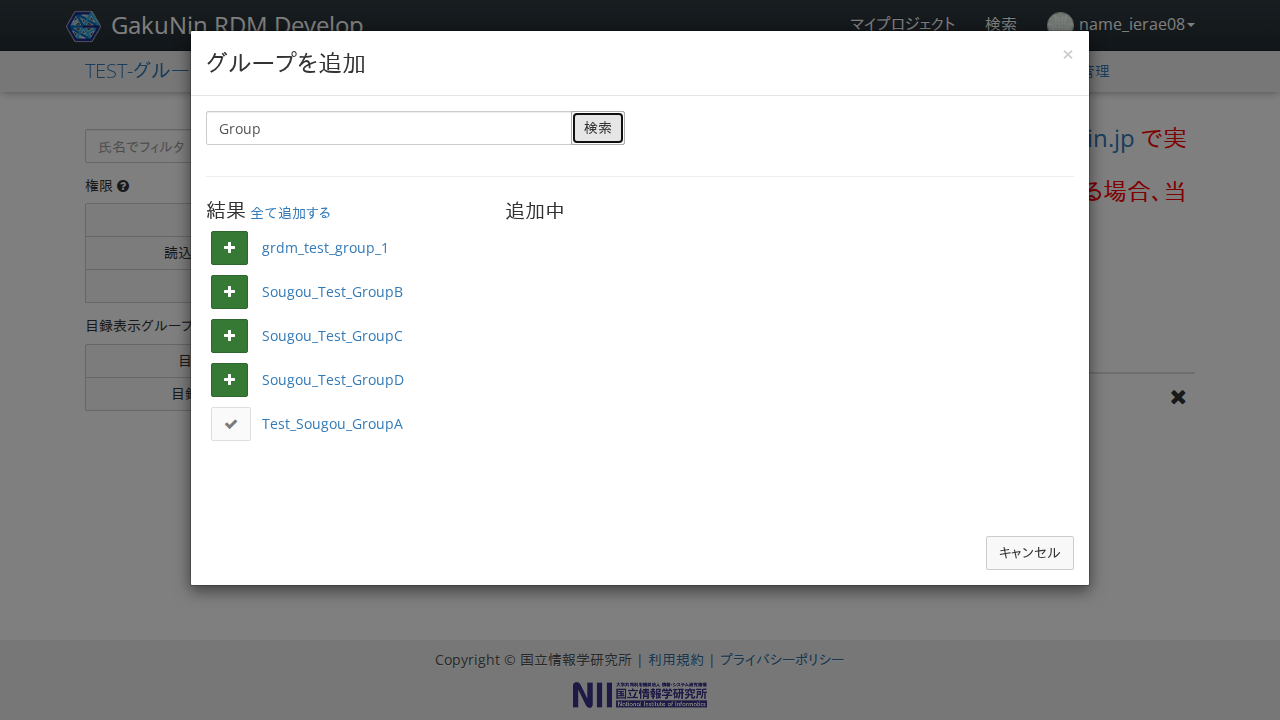

In [32]:
async def _step(page):
    await page.fill('#addGroups input[data-bind*="value:query"]', group_query)
    await page.click('#addGroups input[type="submit"]')
    
    # Group A - should show as already added with checkmark
    row = page.locator('#addGroups tbody tr', has_text=group_a)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_a, timeout=transition_timeout)
    # Verify the checkmark icon is visible (already added indicator)
    await expect(row.locator('i.fa-check-circle-o, i.fa-check')).to_be_visible(timeout=transition_timeout)
    
    # Group B
    row = page.locator('#addGroups tbody tr', has_text=group_b)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_b, timeout=transition_timeout)
    
    # Group C
    row = page.locator('#addGroups tbody tr', has_text=group_c)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_c, timeout=transition_timeout)
    
    # Group D
    row = page.locator('#addGroups tbody tr', has_text=group_d)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_d, timeout=transition_timeout)

await run_pw(_step)

## 「結果」の一覧の既存ユーザー3が所属するグループ(グループB)の横の「＋」ボタンをクリックする

- 「追加中」の一覧に既存ユーザー3が所属するグループ(グループB)が表示されること

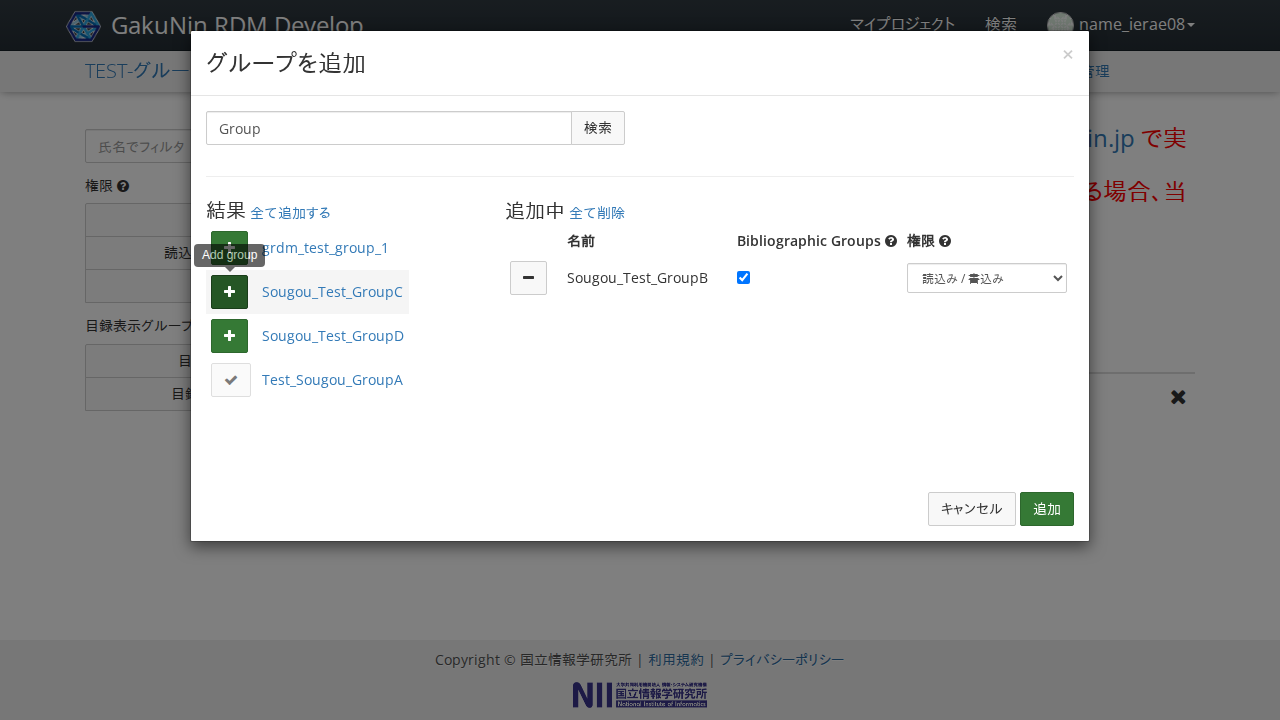

In [33]:
async def _step(page):
    row = page.locator('#addGroups tbody tr', has_text=group_b)
    add_btn = row.locator('a.btn-success.contrib-button.btn-mini')
    await expect(add_btn).to_be_visible(timeout=transition_timeout)
    await add_btn.click()
    modal = page.locator('#addGroups .modal-content')
    await expect(modal).to_be_visible(timeout=transition_timeout)

    # Locate the header span labeled "追加中" (or use "Adding" for English)
    header = modal.locator('span.modal-subheader', has_text='追加中')
    await expect(header).to_be_visible(timeout=transition_timeout)

    await expect(
        page.locator('#addGroups .modal-body .col-md-8 span', has_text=group_b)
    ).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「権限」を「管理者」に設定して、既存ユーザー3が所属するグループ(グループB)の横の「ー」ボタンをクリックする

- 「追加中」の一覧から既存ユーザー3が所属するグループ(グループB)が削除されること

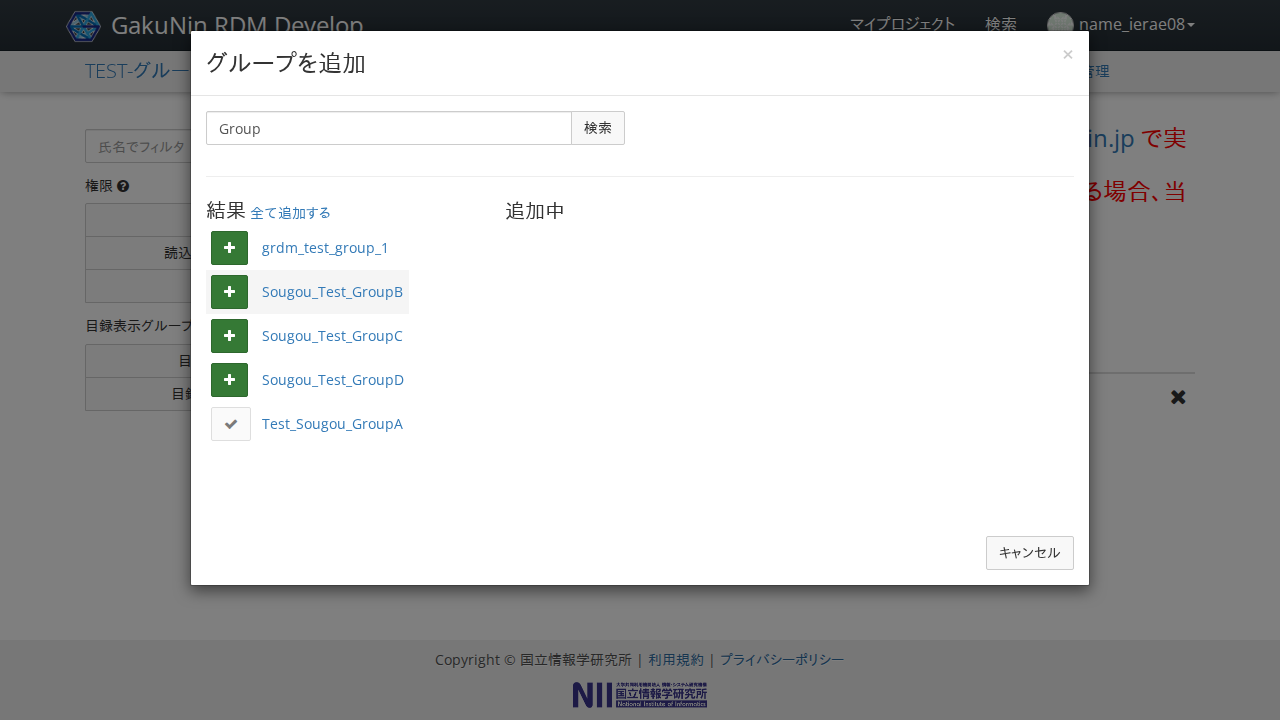

In [34]:
async def _step(page):
    row = page.locator('#addGroups .col-md-8 tbody tr', has_text=group_b)
    remove_btn = row.locator('a.btn.btn-default.contrib-button.btn-mini:has(i.fa-minus)')
    await remove_btn.click()
    await expect(row).not_to_be_visible(timeout=transition_timeout)
await run_pw(_step)

## 「結果」の一覧の既存ユーザー3が所属するグループ(グループB)の横の「＋」ボタンをクリックする

- 「追加中」の一覧に既存ユーザー3が所属するグループ(グループB)が再度表示されること

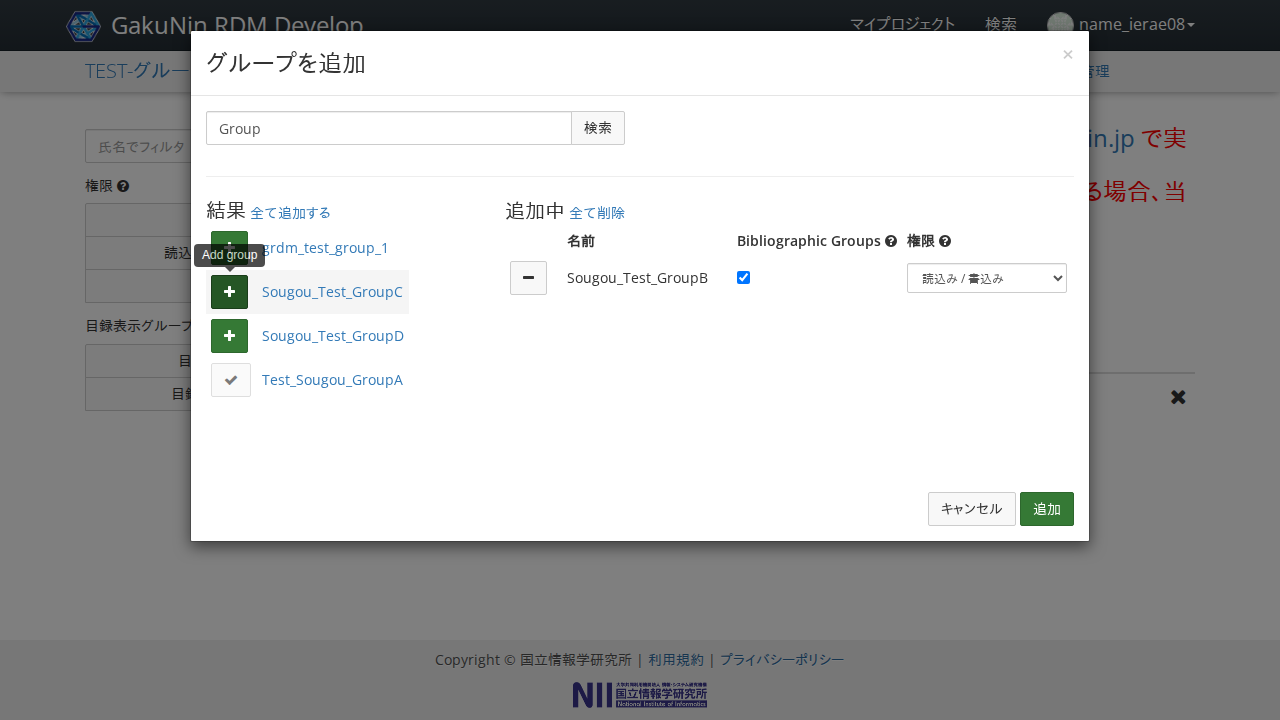

In [35]:
async def _step(page):
    row = page.locator('#addGroups tbody tr', has_text=group_b)
    add_btn = row.locator('a.btn-success.contrib-button.btn-mini')
    await expect(add_btn).to_be_visible(timeout=transition_timeout)
    await add_btn.click()
    modal = page.locator('#addGroups .modal-content')
    await expect(modal).to_be_visible(timeout=transition_timeout)

    # Locate the header span labeled "追加中" (or use "Adding" for English)
    header = modal.locator('span.modal-subheader', has_text='追加中')
    await expect(header).to_be_visible(timeout=transition_timeout)

    await expect(
        page.locator('#addGroups .modal-body .col-md-8 span', has_text=group_b)
    ).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「権限」を「管理者」に設定して、「追加」ボタンをクリックする

- 「グループ」画面に既存ユーザー3が所属するグループ(グループB)が追加されること
- 「グループ」画面に既存ユーザー3が所属するグループ(グループB)の「権限」が「管理者」に設定されていること

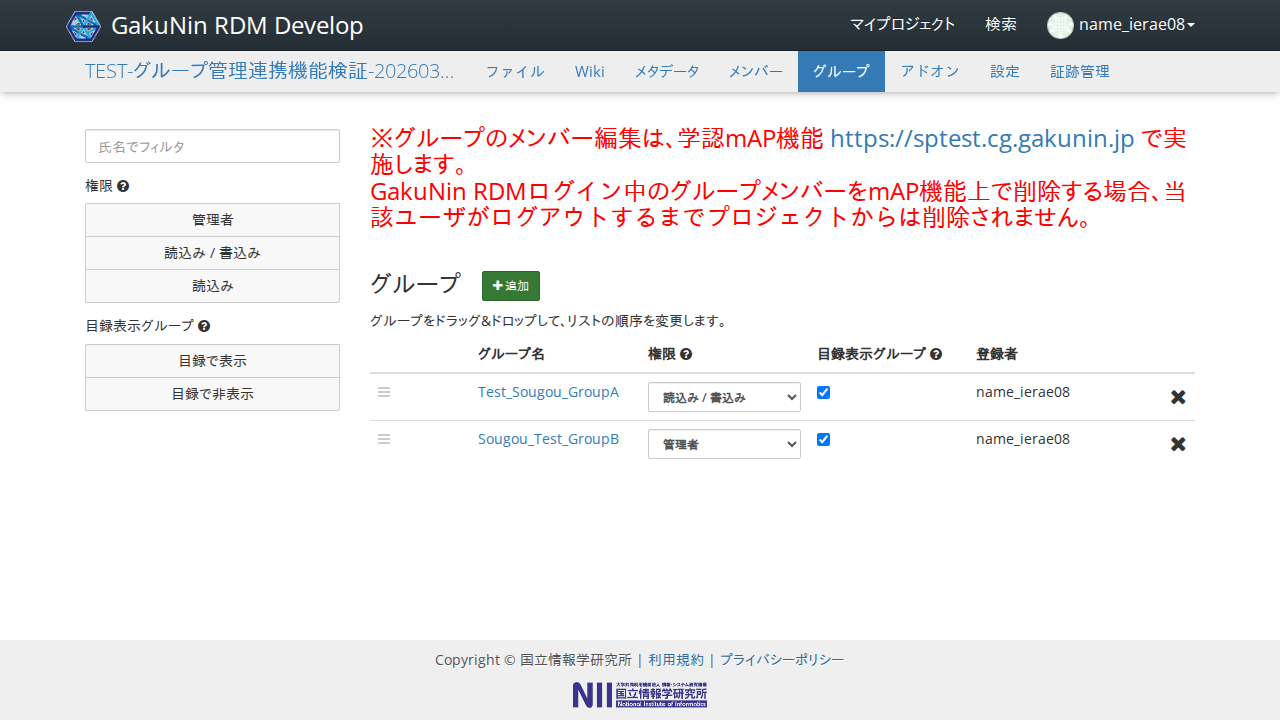

In [36]:
async def _step(page):
    # Locate the selection row on the right (col-md-8) that contains the fullname
    sel_row = page.locator('#addGroups .modal-body .col-md-8 tbody tr', has_text=group_b)
    await expect(sel_row).to_be_visible(timeout=transition_timeout)

    # Locate the permission select inside that row
    permission_select = sel_row.locator('select.form-control.input-sm')

    # Choose the "読込み / 書込み" option by label (locale-safe)
    await permission_select.select_option(label='管理者')

    # Assert the selected option is the expected label
    await expect(permission_select.locator('option:checked')).to_have_text('管理者', timeout=transition_timeout)
    await page.locator('#addGroups .modal-footer a.btn-success', has_text='追加').click()

    # optional: wait for the modal to close (confirm submit)
    await expect(page.locator('#addGroups')).not_to_be_visible(timeout=transition_timeout)

    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_b)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('管理者', timeout=transition_timeout)                                                              

await run_pw(_step)

## 「グループ」のタイトルの横にある「＋追加」をクリックする

- 「グループを追加」ダイアログが表示されること

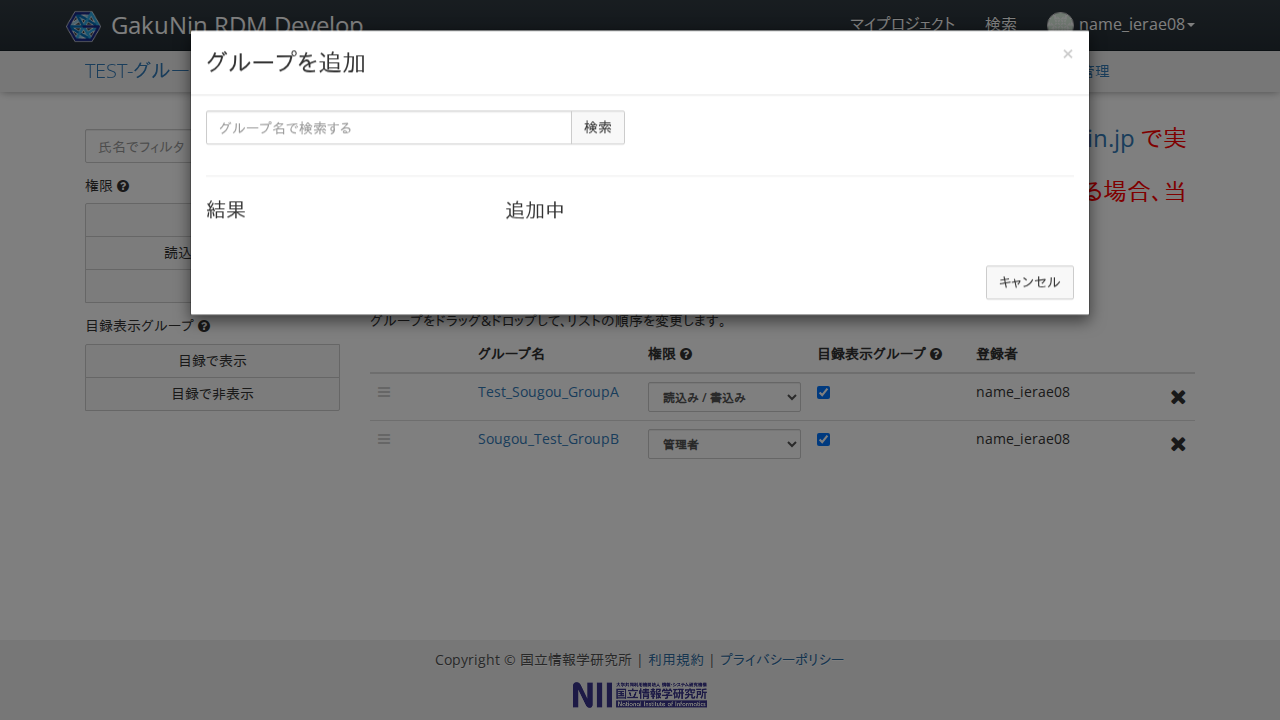

In [37]:
async def _step(page):
    await page.locator('a[href="#addGroups"]').click()
    await expect(page.locator('#addGroups')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#addGroups h3.modal-title')).to_have_text("グループを追加", timeout=transition_timeout)

await run_pw(_step)

##  既存ユーザー4が所属するグループ(グループC)を入力して、「検索」ボタンをクリックする

- 「結果」の一覧に既存ユーザー2が所属するグループ(グループA)が表示されること
- 「結果」の一覧に既存ユーザー3が所属するグループ(グループB)が表示されること
- 「結果」の一覧に既存ユーザー4が所属するグループ(グループC)が表示されること
- 「結果」の一覧に既存ユーザー5が所属するグループ(グループD)が表示されること
- 「結果」の一覧に既存ユーザー2が所属するグループ(グループA)、既存ユーザー3が所属するグループ(グループB)が「✔️(追加済)」として表示されること

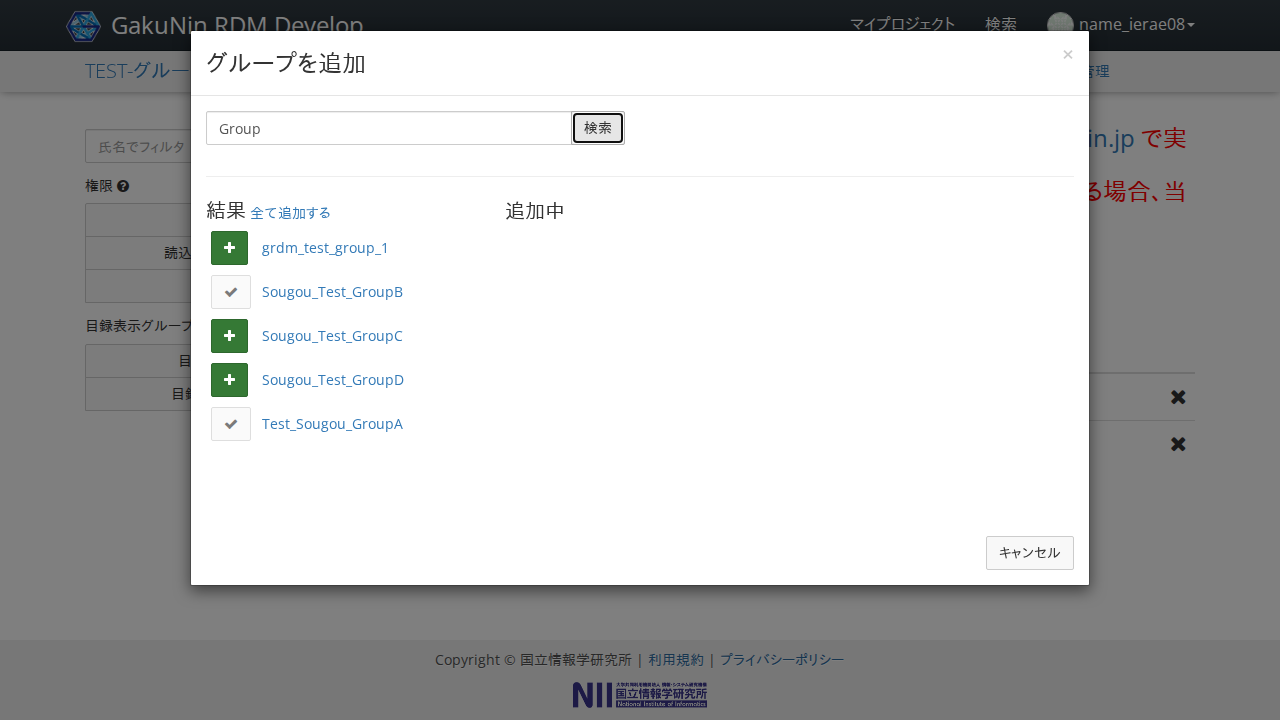

In [38]:
async def _step(page):
    await page.fill('#addGroups input[data-bind*="value:query"]', group_query)
    await page.click('#addGroups input[type="submit"]')
    
    # Group A - should show as already added with checkmark
    row = page.locator('#addGroups tbody tr', has_text=group_a)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_a, timeout=transition_timeout)
    # Verify the checkmark icon is visible (already added indicator)
    await expect(row.locator('i.fa-check-circle-o, i.fa-check')).to_be_visible(timeout=transition_timeout)
    
    # Group B
    row = page.locator('#addGroups tbody tr', has_text=group_b)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_b, timeout=transition_timeout)
    # Verify the checkmark icon is visible (already added indicator)
    await expect(row.locator('i.fa-check-circle-o, i.fa-check')).to_be_visible(timeout=transition_timeout)
    
    # Group C
    row = page.locator('#addGroups tbody tr', has_text=group_c)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_c, timeout=transition_timeout)
    
    # Group D
    row = page.locator('#addGroups tbody tr', has_text=group_d)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_d, timeout=transition_timeout)

await run_pw(_step)

## 「結果」の一覧の既存ユーザー4が所属するグループ(グループC)の横の「＋」ボタンをクリックする

- 「追加中」の一覧に既存ユーザー4が所属するグループ(グループC)が表示されること

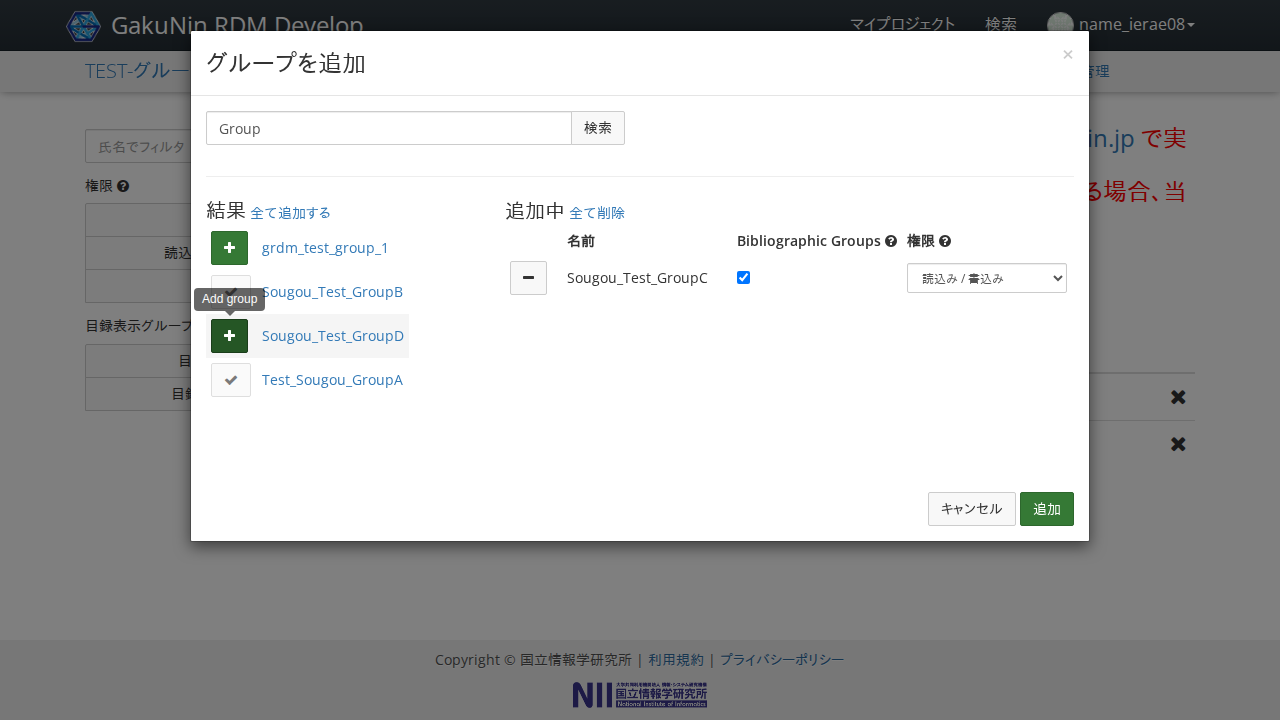

In [39]:
async def _step(page):
    row = page.locator('#addGroups tbody tr', has_text=group_c)
    add_btn = row.locator('a.btn-success.contrib-button.btn-mini')
    await expect(add_btn).to_be_visible(timeout=transition_timeout)
    await add_btn.click()
    modal = page.locator('#addGroups .modal-content')
    await expect(modal).to_be_visible(timeout=transition_timeout)

    # Locate the header span labeled "追加中" (or use "Adding" for English)
    header = modal.locator('span.modal-subheader', has_text='追加中')
    await expect(header).to_be_visible(timeout=transition_timeout)

    await expect(
        page.locator('#addGroups .modal-body .col-md-8 span', has_text=group_c)
    ).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「権限」を「管理者」に設定して、「追加」ボタンをクリックする

- 「グループ」画面に既存ユーザー4が所属するグループ(グループC)が追加されること
- 「グループ」画面に既存ユーザー4が所属するグループ(グループC)の「権限」が「管理者」に設定されていること

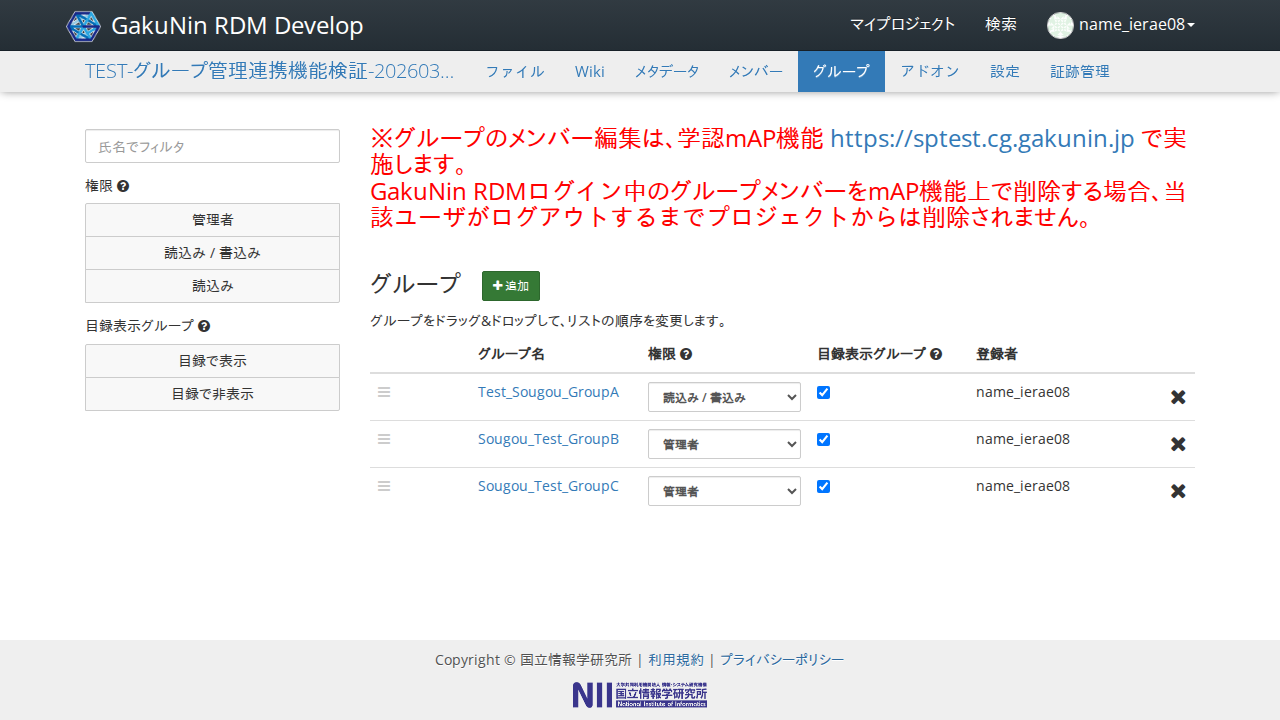

In [40]:
async def _step(page):
    # Locate the selection row on the right (col-md-8) that contains the fullname
    sel_row = page.locator('#addGroups .modal-body .col-md-8 tbody tr', has_text=group_c)
    await expect(sel_row).to_be_visible(timeout=transition_timeout)

    # Locate the permission select inside that row
    permission_select = sel_row.locator('select.form-control.input-sm')

    # Choose the "読込み" option by label (locale-safe)
    await permission_select.select_option(label='管理者')

    # Assert the selected option is the expected label
    await expect(permission_select.locator('option:checked')).to_have_text('管理者', timeout=transition_timeout)
    await page.locator('#addGroups .modal-footer a.btn-success', has_text='追加').click()

    # optional: wait for the modal to close (confirm submit)
    await expect(page.locator('#addGroups')).not_to_be_visible(timeout=transition_timeout)

    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_c)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('管理者', timeout=transition_timeout)   
await run_pw(_step)

## 「グループ」のタイトルの横にある「＋追加」をクリックする

- 「グループを追加」ダイアログが表示されること

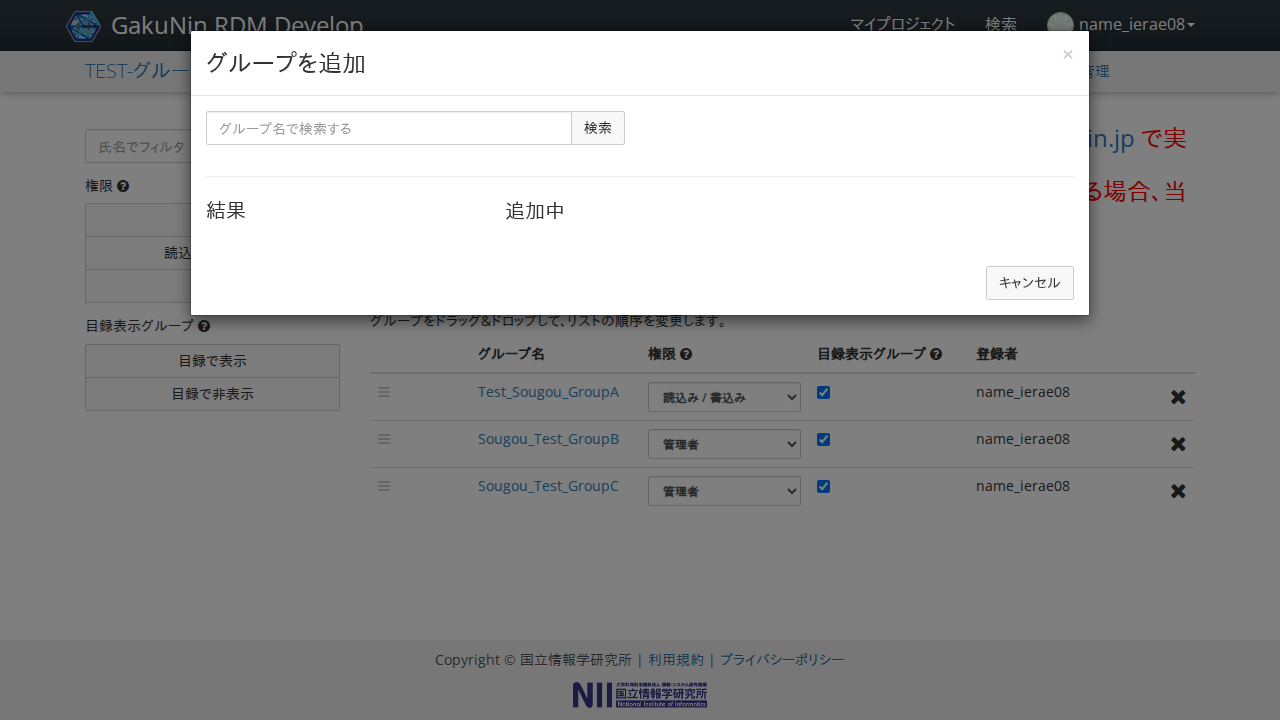

In [41]:
async def _step(page):
    await page.locator('a[href="#addGroups"]').click()
    await expect(page.locator('#addGroups')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#addGroups h3.modal-title')).to_have_text("グループを追加", timeout=transition_timeout)

await run_pw(_step)

##  既存ユーザー5が所属するグループ(グループD)を入力して、「検索」ボタンをクリックする

- 「結果」の一覧に既存ユーザー2が所属するグループ(グループA)が表示されること
- 「結果」の一覧に既存ユーザー3が所属するグループ(グループB)が表示されること
- 「結果」の一覧に既存ユーザー4が所属するグループ(グループC)が表示されること
- 「結果」の一覧に既存ユーザー5が所属するグループ(グループD)が表示されること
- 「結果」の一覧に既存ユーザー2が所属するグループ(グループA)、既存ユーザー3が所属するグループ(グループB)、既存ユーザー4が所属するグループ(グループC)が「✔️(追加済)」として表示されること

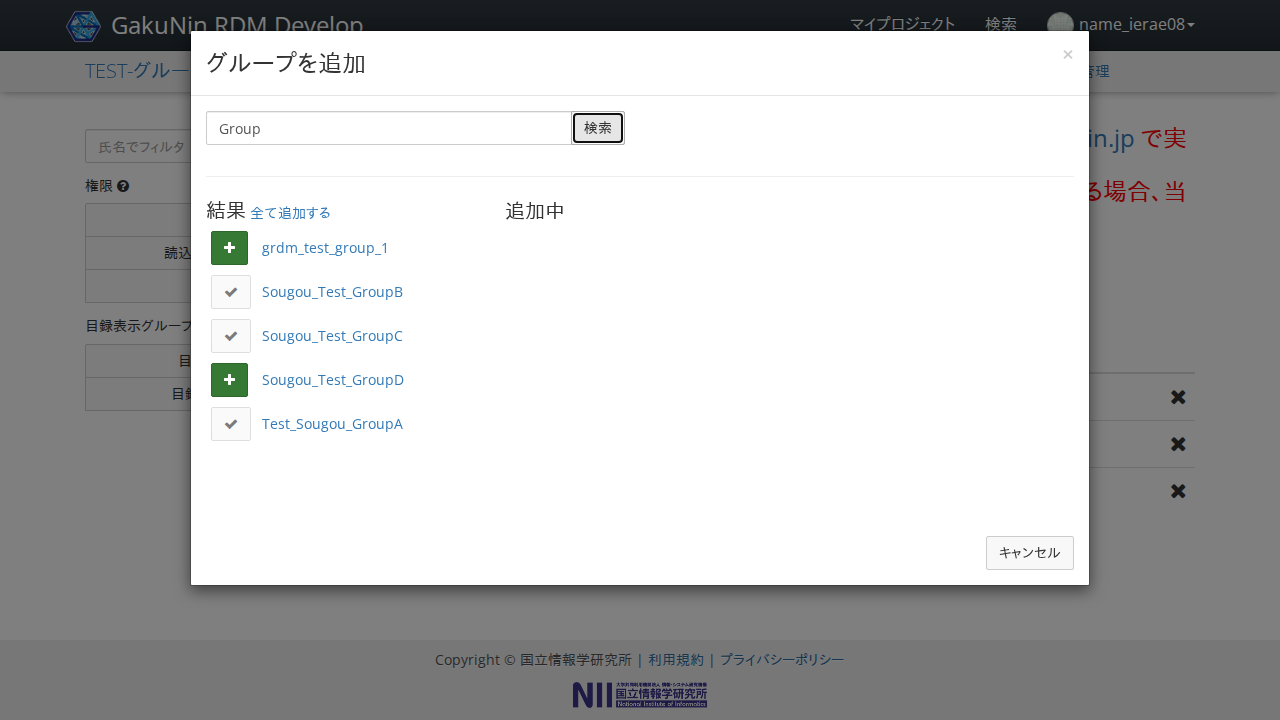

In [42]:
async def _step(page):
    await page.fill('#addGroups input[data-bind*="value:query"]', group_query)
    await page.click('#addGroups input[type="submit"]')
    
    # Group A - should show as already added with checkmark
    row = page.locator('#addGroups tbody tr', has_text=group_a)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_a, timeout=transition_timeout)
    # Verify the checkmark icon is visible (already added indicator)
    await expect(row.locator('i.fa-check-circle-o, i.fa-check')).to_be_visible(timeout=transition_timeout)
    
    # Group B
    row = page.locator('#addGroups tbody tr', has_text=group_b)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_b, timeout=transition_timeout)
    # Verify the checkmark icon is visible (already added indicator)
    await expect(row.locator('i.fa-check-circle-o, i.fa-check')).to_be_visible(timeout=transition_timeout)
    
    # Group C
    row = page.locator('#addGroups tbody tr', has_text=group_c)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_c, timeout=transition_timeout)
    # Verify the checkmark icon is visible (already added indicator)
    await expect(row.locator('i.fa-check-circle-o, i.fa-check')).to_be_visible(timeout=transition_timeout)
    
    # Group D
    row = page.locator('#addGroups tbody tr', has_text=group_d)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_d, timeout=transition_timeout)

await run_pw(_step)

## 「結果」の一覧の既存ユーザー5が所属するグループ(グループD)の横の「＋」ボタンをクリックする

- 「追加中」の一覧に既存ユーザー5が所属するグループ(グループD)が表示されること

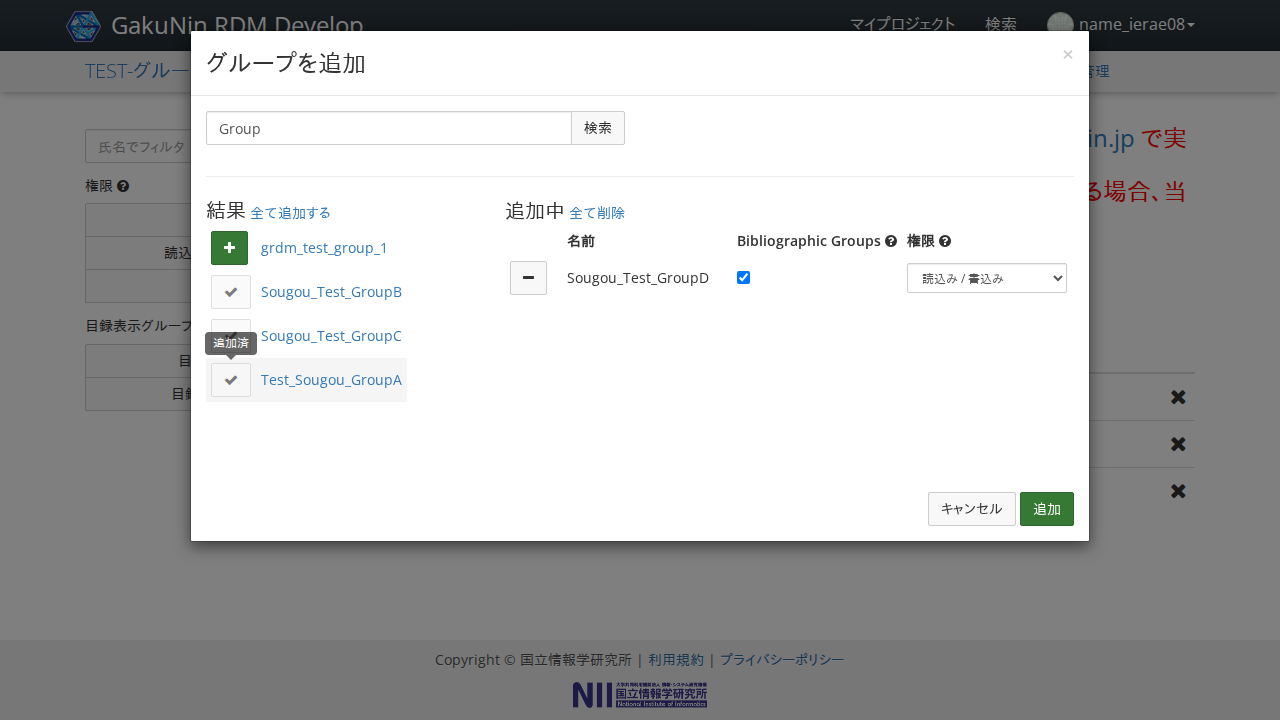

In [43]:
async def _step(page):
    row = page.locator('#addGroups tbody tr', has_text=group_d)
    add_btn = row.locator('a.btn-success.contrib-button.btn-mini')
    await expect(add_btn).to_be_visible(timeout=transition_timeout)
    await add_btn.click()
    modal = page.locator('#addGroups .modal-content')
    await expect(modal).to_be_visible(timeout=transition_timeout)

    # Locate the header span labeled "追加中" (or use "Adding" for English)
    header = modal.locator('span.modal-subheader', has_text='追加中')
    await expect(header).to_be_visible(timeout=transition_timeout)

    await expect(
        page.locator('#addGroups .modal-body .col-md-8 span', has_text=group_d)
    ).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「権限」を「読込み」に設定して、「追加」ボタンをクリックする

- 「グループ」画面に既存ユーザー5が所属するグループ(グループD)が追加されること
- 「グループ」画面に既存ユーザー5が所属するグループ(グループD)の「権限」が「読込み」に設定されていること

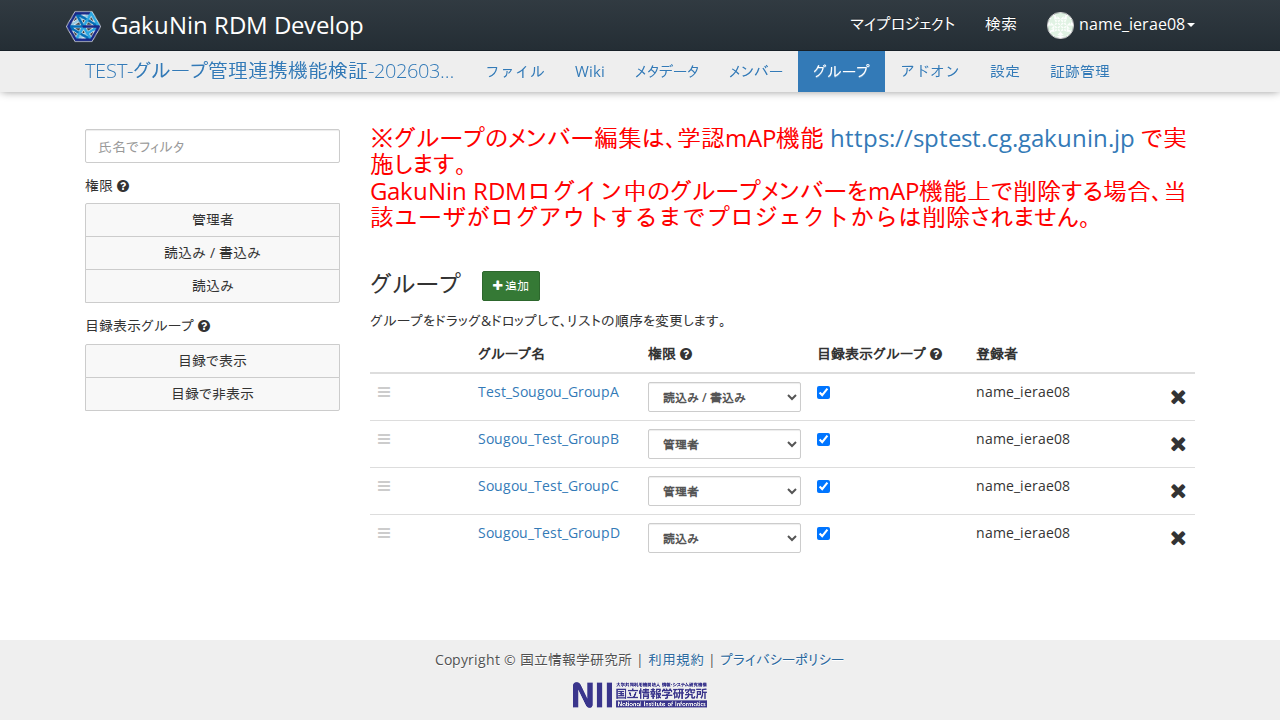

In [44]:
async def _step(page):
    # Locate the selection row on the right (col-md-8) that contains the fullname
    sel_row = page.locator('#addGroups .modal-body .col-md-8 tbody tr', has_text=group_d)
    await expect(sel_row).to_be_visible(timeout=transition_timeout)

    # Locate the permission select inside that row
    permission_select = sel_row.locator('select.form-control.input-sm')

    # Choose the "読込み" option by label (locale-safe)
    await permission_select.select_option(label='読込み')

    # Assert the selected option is the expected label
    await expect(permission_select.locator('option:checked')).to_have_text('読込み', timeout=transition_timeout)
    await page.locator('#addGroups .modal-footer a.btn-success', has_text='追加').click()

    # optional: wait for the modal to close (confirm submit)
    await expect(page.locator('#addGroups')).not_to_be_visible(timeout=transition_timeout)

    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_d)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み', timeout=transition_timeout)   
await run_pw(_step)

##  プロジェクトダッシュボードの上部メニューから「グループ」をクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
  - 既存ユーザー2 が所属するグループ(グループA): 読込み/書込み
  - 既存ユーザー3 が所属するグループ(グループB): 管理者
  - 既存ユーザー4 が所属するグループ(グループC): 管理者
  - 既存ユーザー5 が所属するグループ(グループD): 読込み

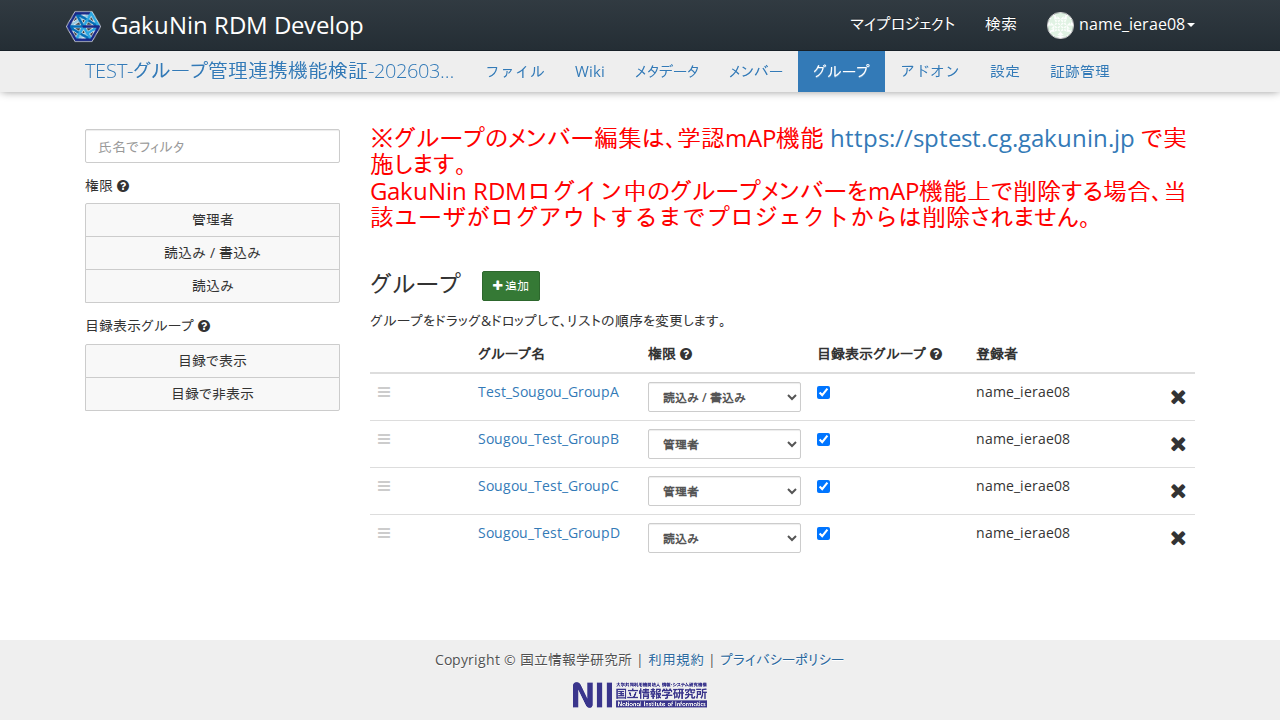

In [ ]:
async def _step(page):
    await page.locator("#projectSubnav").get_by_role("link", name="グループ", exact=True).click()
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)

    # Group A
    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_a)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)

    # Group B
    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_b)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('管理者', timeout=transition_timeout)

    # Group C
    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_c)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('管理者', timeout=transition_timeout)

    # Group D
    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_d)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み', timeout=transition_timeout)
await run_pw(_step)

## 「名前」項目の既存ユーザー3が所属するグループ(グループB)の列の右端の「×」ボタンをクリックする

- 「グループを削除」ダイアログが表示されること

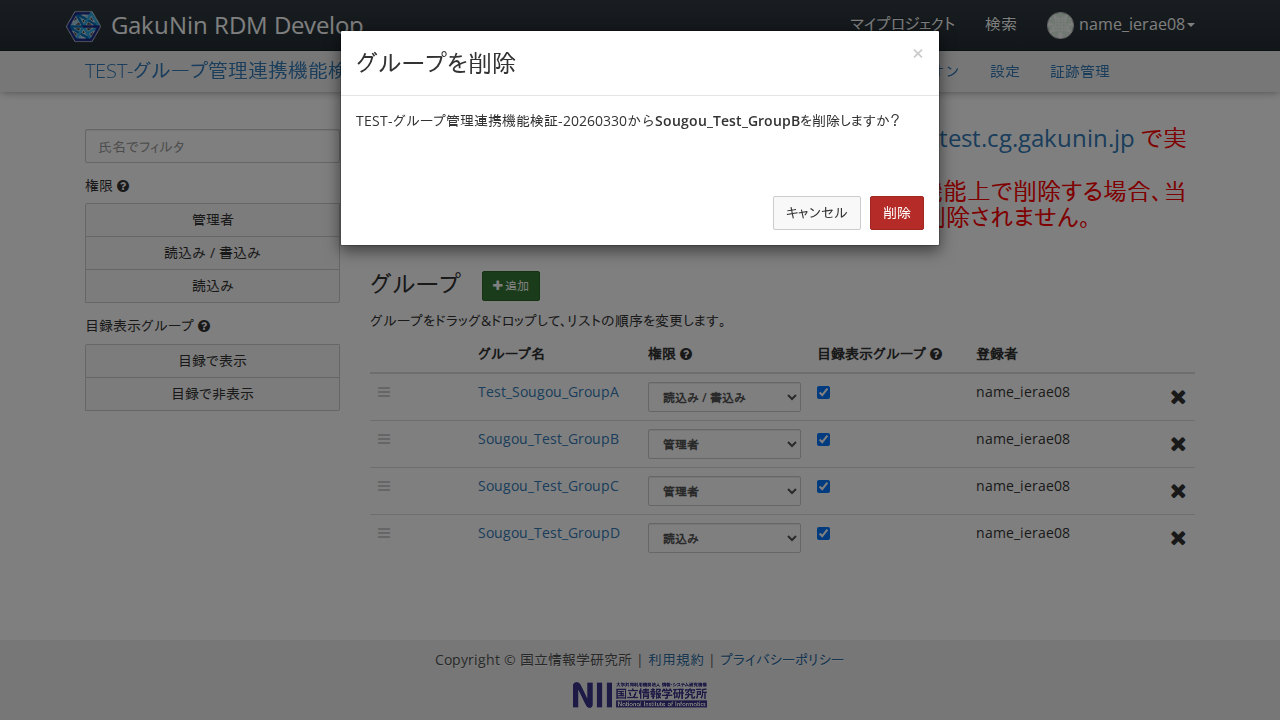

In [46]:
async def _step(page):
    # Click the remove button (×) for Group B
    group_b_link = page.get_by_role("link", name=group_b)
    group_b_row = group_b_link.locator("xpath=ancestor::tr[1]")
    remove_button = group_b_row.locator('span[data-bind*="remove"] i.fa-times')
    time.sleep(1)
    await remove_button.click()

    # Verify the "グループを削除" dialog appears
    time.sleep(1)
    await expect(page.locator('text=グループを削除')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「グループを削除」ダイアログの「削除」ボタンをクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
  - 既存ユーザー2 が所属するグループ(グループA): 読込み/書込み
  - 既存ユーザー4 が所属するグループ(グループC): 管理者
  - 既存ユーザー5 が所属するグループ(グループD): 読込み

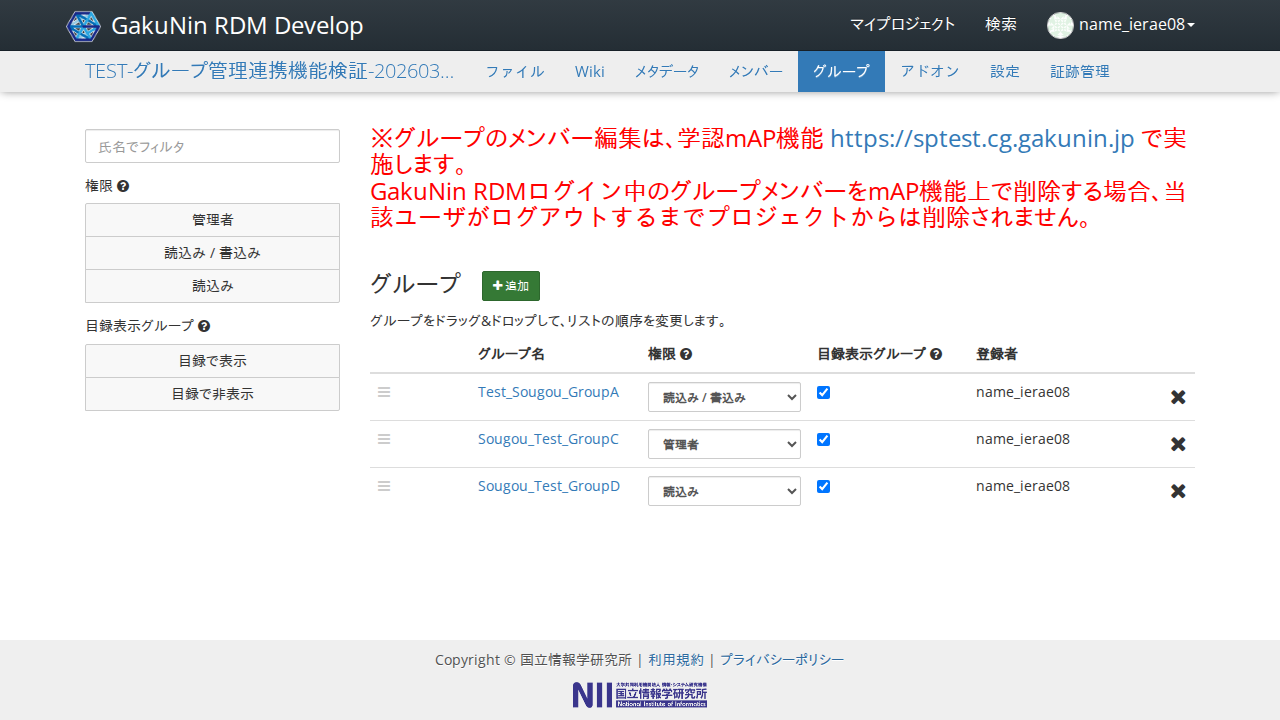

In [ ]:
async def _step(page):
    # Verify the "グループを削除" dialog appears again
    await expect(page.locator('#removeGroup')).to_be_visible(timeout=transition_timeout)

    # Click the Remove button in the dialog
    await page.locator('#removeGroup a.btn-danger[data-bind*="submit"]').click()
    time.sleep(1)
    # Verify the Groups page is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)

    # Verify Group B is removed and other groups remain with correct permissions
    # Group A - should still be visible
    group_link = page.get_by_role("link", name=group_a)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)

    # Group C - should still be visible
    group_link = page.get_by_role("link", name=group_c)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('管理者', timeout=transition_timeout)

    # Group D - should still be visible
    group_link = page.get_by_role("link", name=group_d)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み', timeout=transition_timeout)

await run_pw(_step)

## 「グループ」のタイトルの横にある「＋追加」をクリックする

- 「グループを追加」ダイアログが表示されること

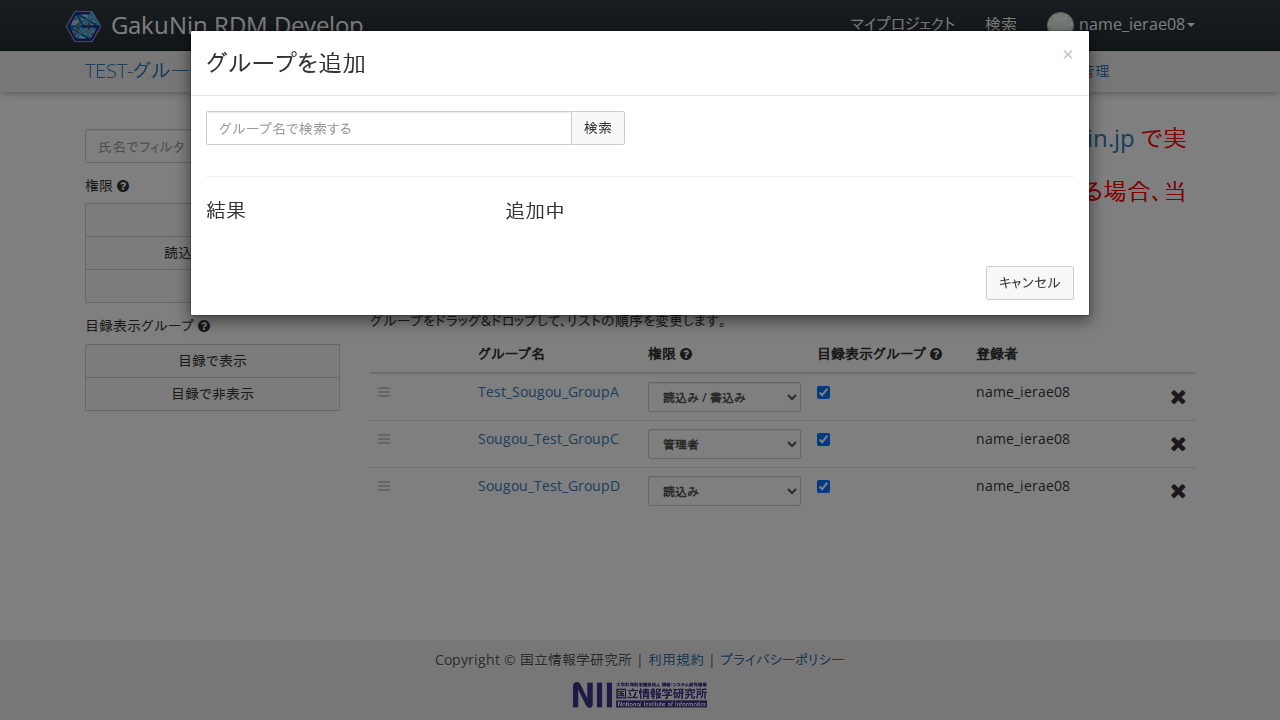

In [48]:
async def _step(page):
    await page.locator('a[href="#addGroups"]').click()
    await expect(page.locator('#addGroups')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#addGroups h3.modal-title')).to_have_text("グループを追加", timeout=transition_timeout)

await run_pw(_step)

## 既存ユーザー3が所属するグループ(グループB)を入力して、「検索」ボタンをクリックする

- 「結果」の一覧に既存ユーザー2が所属するグループ(グループA)が表示されること
- 「結果」の一覧に既存ユーザー3が所属するグループ(グループB)が表示されること
- 「結果」の一覧に既存ユーザー4が所属するグループ(グループC)が表示されること
- 「結果」の一覧に既存ユーザー5が所属するグループ(グループD)が表示されること
- 「結果」の一覧に既存ユーザー2が所属するグループ(グループA)、既存ユーザー4が所属するグループ(グループC)、既存ユーザー5が所属するグループ(グループD)が「✔️(追加済)」として表示されること

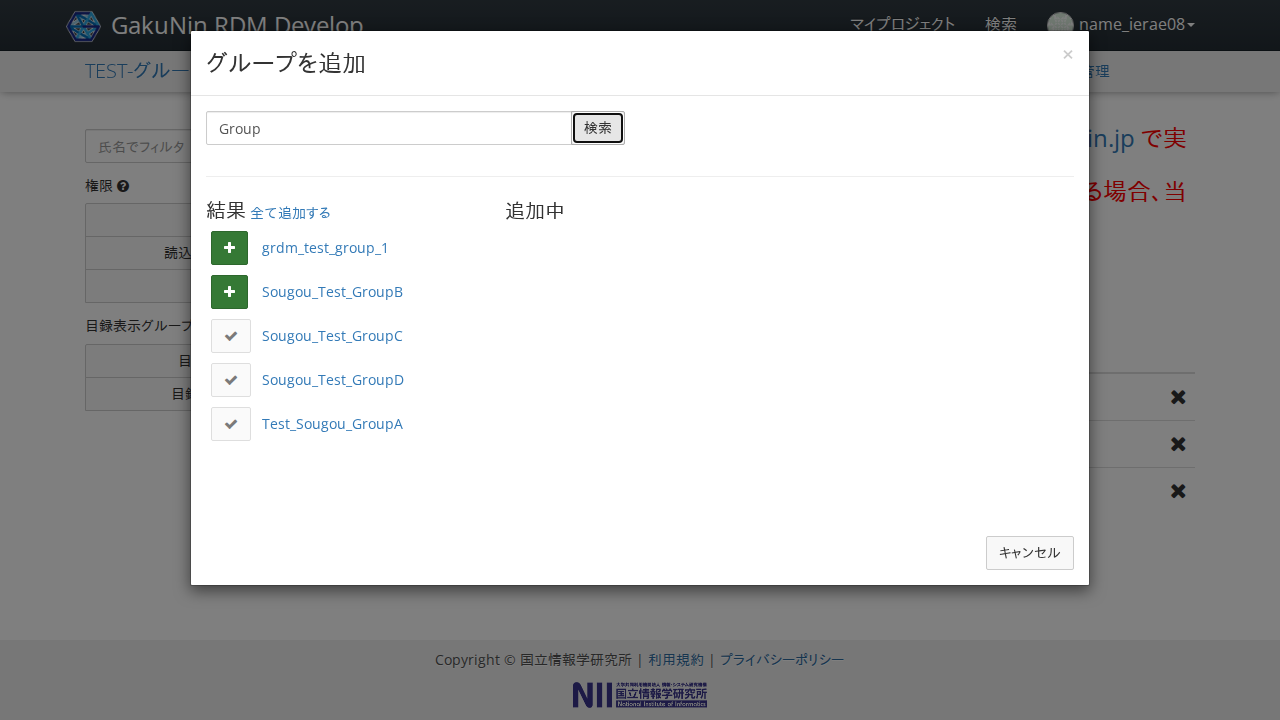

In [49]:
async def _step(page):
    await page.fill('#addGroups input[data-bind*="value:query"]', group_query)
    await page.click('#addGroups input[type="submit"]')

    # Group A - should show as already added with checkmark
    row = page.locator('#addGroups tbody tr', has_text=group_a)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_a, timeout=transition_timeout)
    # Verify the checkmark icon is visible (already added indicator)
    await expect(row.locator('i.fa-check-circle-o, i.fa-check')).to_be_visible(timeout=transition_timeout)
    
    # Group B
    row = page.locator('#addGroups tbody tr', has_text=group_b)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_b, timeout=transition_timeout)
  
    # Group C
    row = page.locator('#addGroups tbody tr', has_text=group_c)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_c, timeout=transition_timeout)
    # Verify the checkmark icon is visible (already added indicator)
    await expect(row.locator('i.fa-check-circle-o, i.fa-check')).to_be_visible(timeout=transition_timeout)

    # Group D
    row = page.locator('#addGroups tbody tr', has_text=group_d)
    await expect(row).to_be_visible(timeout=transition_timeout)
    await expect(row.locator('span[data-bind*="group.name"]')).to_have_text(group_d, timeout=transition_timeout)
    # Verify the checkmark icon is visible (already added indicator)
    await expect(row.locator('i.fa-check-circle-o, i.fa-check')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「結果」の一覧の既存ユーザー3が所属するグループ(グループB)の横の「＋」ボタンをクリックする

- 「追加中」の一覧に既存ユーザー3が所属するグループ(グループB)が表示されること

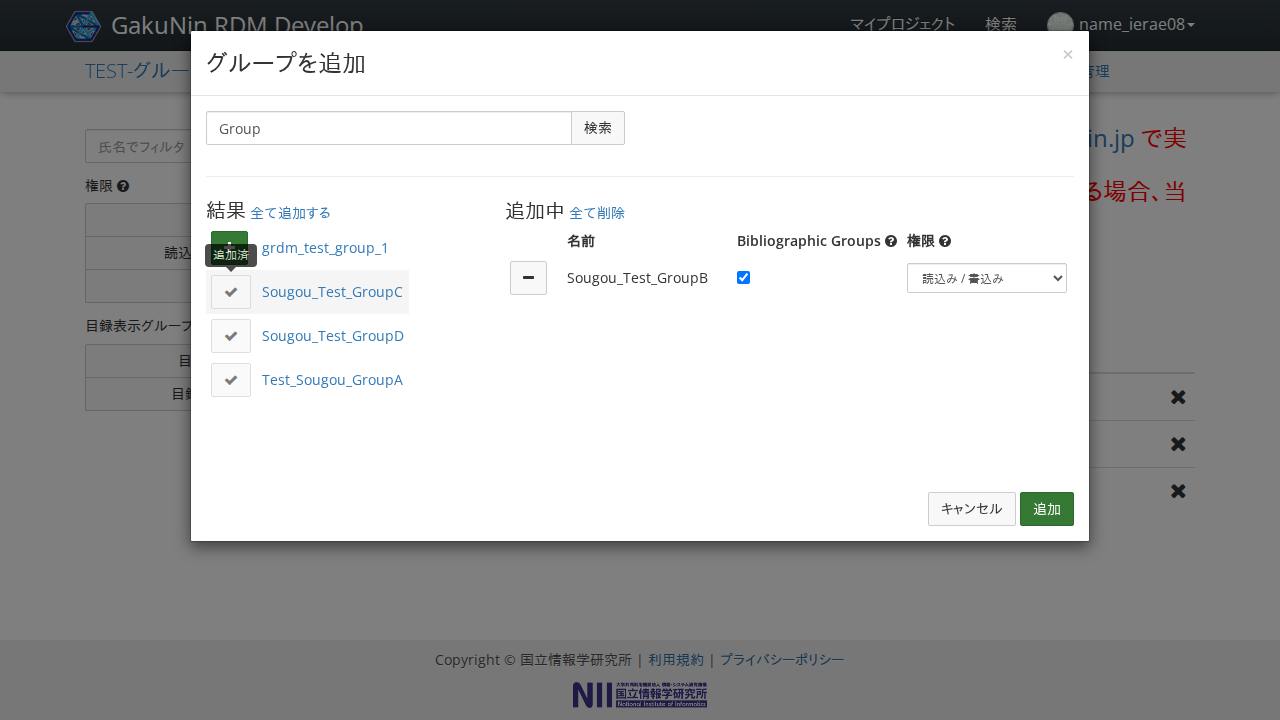

In [50]:
async def _step(page):
    row = page.locator('#addGroups tbody tr', has_text=group_b)
    add_btn = row.locator('a.btn-success.contrib-button.btn-mini')
    await expect(add_btn).to_be_visible(timeout=transition_timeout)
    await add_btn.click()
    modal = page.locator('#addGroups .modal-content')
    await expect(modal).to_be_visible(timeout=transition_timeout)

    # Locate the header span labeled "追加中" (or use "Adding" for English)
    header = modal.locator('span.modal-subheader', has_text='追加中')
    await expect(header).to_be_visible(timeout=transition_timeout)

    await expect(
        page.locator('#addGroups .modal-body .col-md-8 span', has_text=group_b)
    ).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「権限」を「読込み/書込み」に設定して、「追加」ボタンをクリックする

- 「グループ」画面に既存ユーザー3が所属するグループ(グループB)が追加されること
- 「グループ」画面に既存ユーザー3が所属するグループ(グループB)の「権限」が「読込み/書込み」に設定されていること

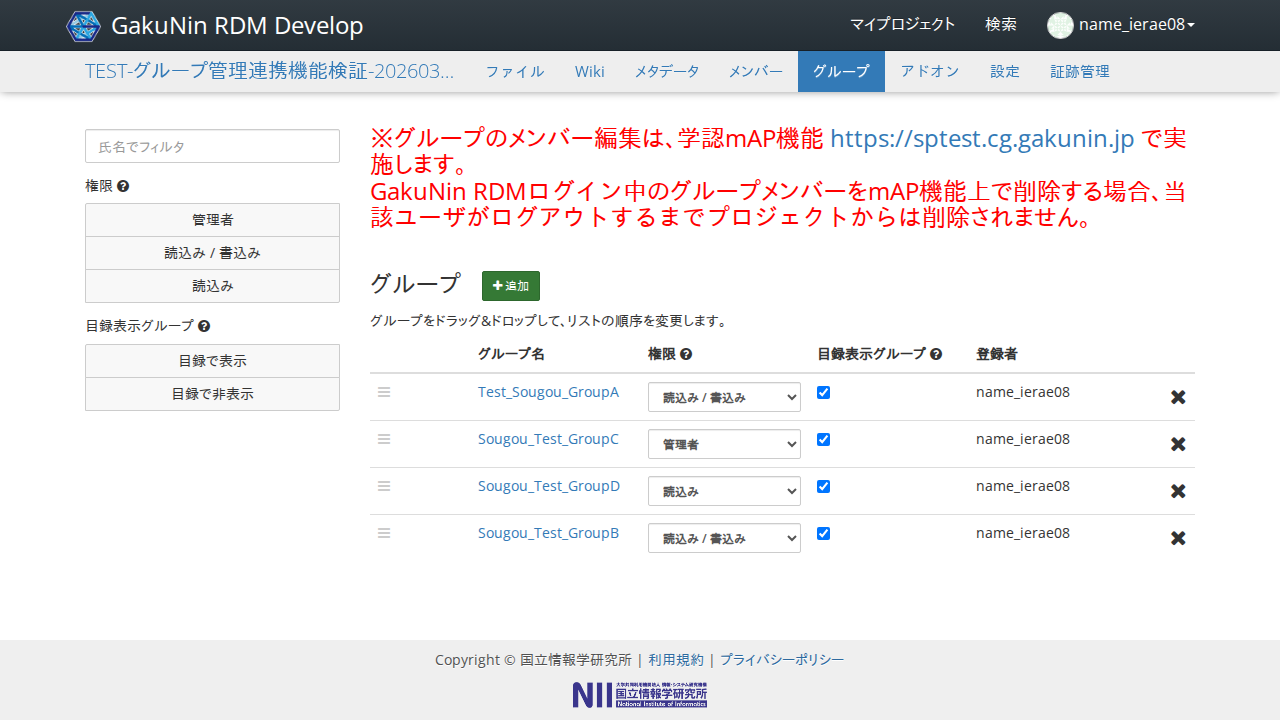

In [51]:
async def _step(page):
    # Locate the selection row on the right (col-md-8) that contains the fullname
    sel_row = page.locator('#addGroups .modal-body .col-md-8 tbody tr', has_text=group_b)
    await expect(sel_row).to_be_visible(timeout=transition_timeout)

    # Locate the permission select inside that row
    permission_select = sel_row.locator('select.form-control.input-sm')

    # Choose the "読込み / 書込み" option by label (locale-safe)
    await permission_select.select_option(label='読込み / 書込み')

    # Assert the selected option is the expected label
    await expect(permission_select.locator('option:checked')).to_have_text('読込み / 書込み', timeout=transition_timeout)
    await page.locator('#addGroups .modal-footer a.btn-success', has_text='追加').click()

    # optional: wait for the modal to close (confirm submit)
    await expect(page.locator('#addGroups')).not_to_be_visible(timeout=transition_timeout)

    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_b)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)                                                              

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「グループ」をクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
  - 既存ユーザー2 が所属するグループ(グループA): 読込み/書込み
  - 既存ユーザー3 が所属するグループ(グループB): 読込み/書込み
  - 既存ユーザー4 が所属するグループ(グループC): 管理者
  - 既存ユーザー5 が所属するグループ(グループD): 読込み

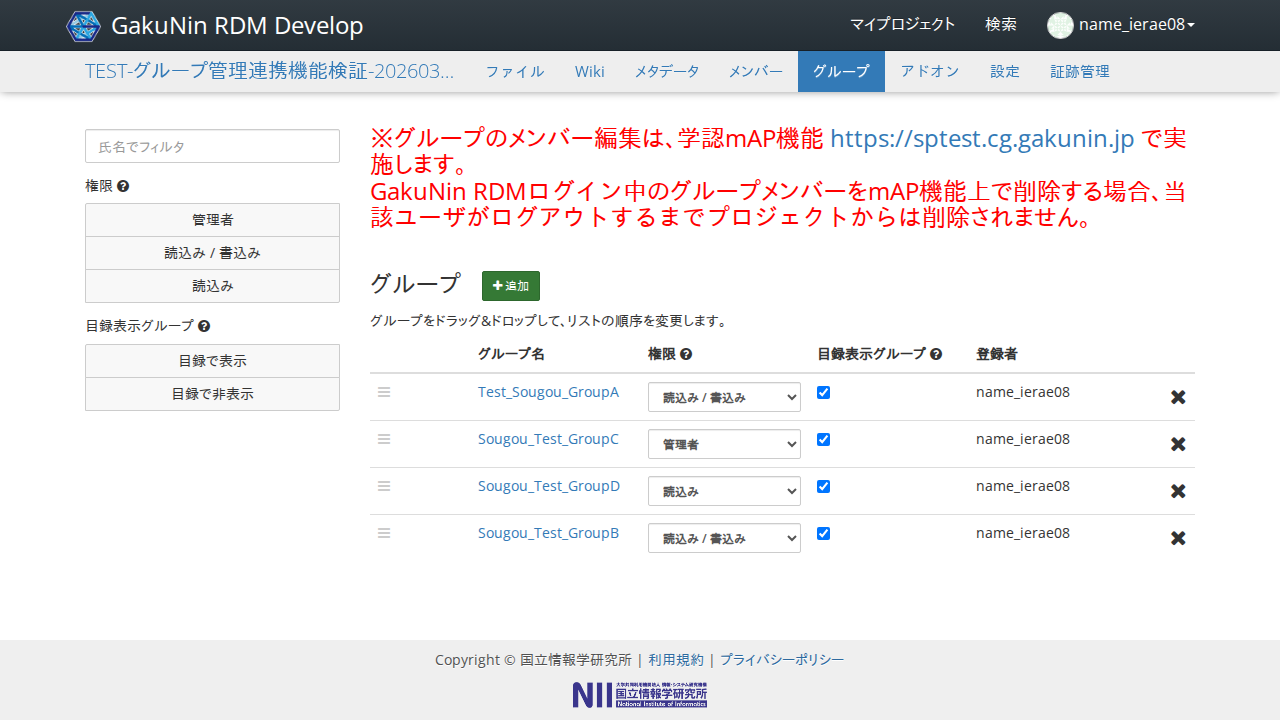

In [ ]:
async def _step(page):
    await page.locator("#projectSubnav").get_by_role("link", name="グループ", exact=True).click()
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)

    # Group A
    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_a)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)

    # Group B
    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_b)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)

    # Group C
    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_c)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('管理者', timeout=transition_timeout)

    # Group D
    # find the group link (use .nth(0) to avoid calling a Locator)
    group_link = page.get_by_role("link", name=group_d)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    
    # get the table row containing that link
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row).to_be_visible(timeout=transition_timeout)

    # assert the permission text in the same row - target the span specifically
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み', timeout=transition_timeout)
await run_pw(_step)

## 「名前」項目の既存ユーザー3が所属するグループ(グループB)の「権限」項目を「読込み」に変更し、「変更を破棄」ボタンをクリックする

- 「権限」項目の変更が取り消されて、既存ユーザー3が所属するグループの「権限」項目に「読込み/書込み」が表示されること

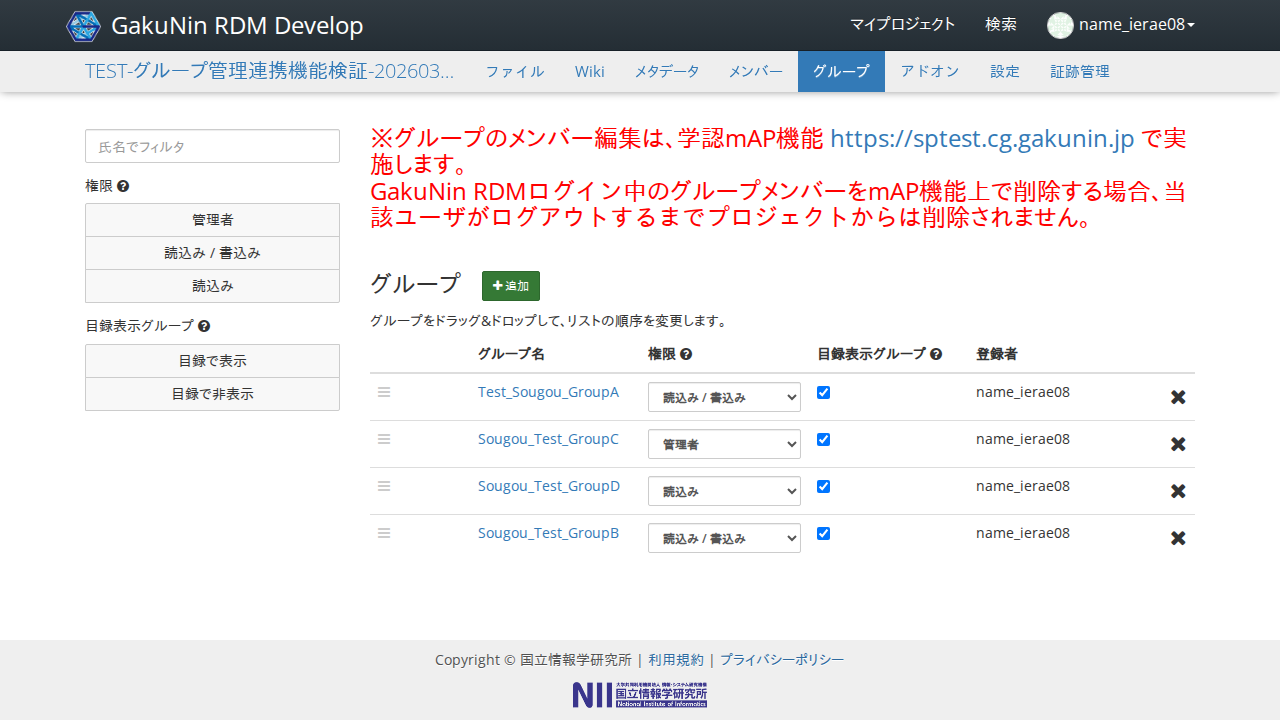

In [53]:
async def _step(page):
    # Locate Group B's row
    group_b_link = page.get_by_role("link", name=group_b)
    await expect(group_b_link).to_be_visible(timeout=transition_timeout)
    
    group_b_row = group_b_link.locator("xpath=ancestor::tr[1]")
    await expect(group_b_row).to_be_visible(timeout=transition_timeout)
    
    # Verify current permission is "読込み / 書込み"
    await expect(group_b_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)
    
    # Locate the permission select dropdown in Group B's row
    permission_select = group_b_row.locator('select.form-control')
    await expect(permission_select).to_be_visible(timeout=transition_timeout)
    
    # Change permission to "読込み" (Read)
    await permission_select.select_option(label='読込み')
    
    # Verify the option is selected
    await expect(permission_select.locator('option:checked')).to_have_text('読込み', timeout=transition_timeout)
    
    # Click the "変更を破棄" (Discard Changes) button
    discard_button = page.locator('button:has-text("変更を破棄"), a:has-text("変更を破棄")')
    await discard_button.click()
    
    # Verify the permission reverts back to "読込み / 書込み"
    await expect(group_b_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)

await run_pw(_step)

## 「名前」項目の既存ユーザー3が所属するグループ(グループB)の「権限」項目を「読込み」に変更し、「変更を保存」ボタンをクリックする

- 「変更を保存しますか？」ダイアログが表示されること

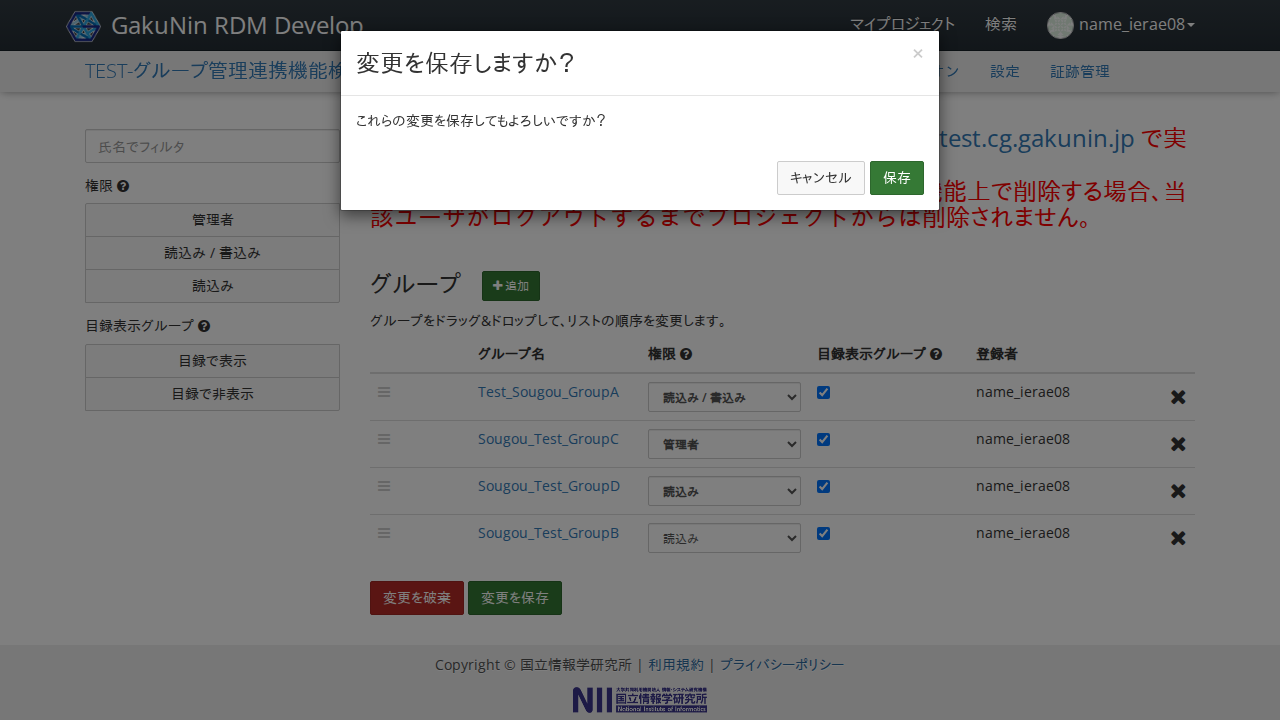

In [54]:
async def _step(page):
    # Locate Group B's row
    group_b_link = page.get_by_role("link", name=group_b)
    await expect(group_b_link).to_be_visible(timeout=transition_timeout)
    
    group_b_row = group_b_link.locator("xpath=ancestor::tr[1]")
    await expect(group_b_row).to_be_visible(timeout=transition_timeout)
    
    # Verify current permission is "読込み / 書込み"
    await expect(group_b_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)
    
    # Locate the permission select dropdown in Group B's row
    permission_select = group_b_row.locator('select.form-control')
    await expect(permission_select).to_be_visible(timeout=transition_timeout)
    
    # Change permission to "読込み" (Read)
    await permission_select.select_option(label='読込み')
    
    # Verify the option is selected
    await expect(permission_select.locator('option:checked')).to_have_text('読込み', timeout=transition_timeout)
    
    # Click the "変更を保存" (Save Changes) button
    save_button = page.locator('button:has-text("変更を保存"), a:has-text("変更を保存")')
    await save_button.click()
    
    # Verify the confirmation dialog appears
    await expect(page.locator('text=変更を保存しますか？')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「変更を保存しますか？」ダイアログの「保存」ボタンをクリックする。

- 既存ユーザー3が所属するグループ(グループB)の「権限」項目に「読込み」が表示されること
- 各グループが以下の通りとなっていること。
  - 既存ユーザー2 が所属するグループ(グループA): 読込み/書込み
  - 既存ユーザー3 が所属するグループ(グループB): 読込み
  - 既存ユーザー4 が所属するグループ(グループC): 管理者
  - 既存ユーザー5 が所属するグループ(グループD): 読込み

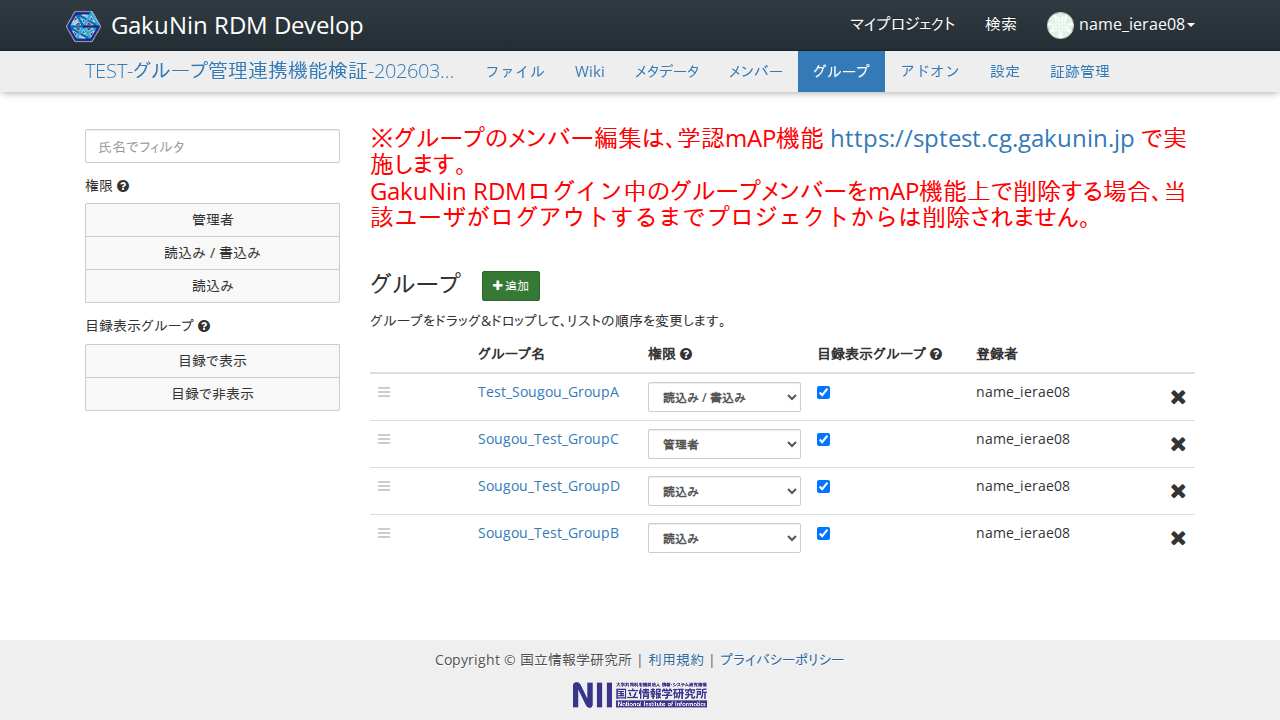

In [55]:
async def _step(page):
    # Verify the confirmation dialog appears
    await expect(page.locator('text=変更を保存しますか？')).to_be_visible(timeout=transition_timeout)
    
    # Click the "保存" (Save) button in the confirmation dialog
    confirm_save_button = page.locator('button.btn-success[data-bb-handler="confirm"]')
    await confirm_save_button.click()
    
    # Wait for dialog to close
    await expect(page.locator('text=変更を保存しますか？')).not_to_be_visible(timeout=transition_timeout)
    
    # Verify all groups and their permissions
    
    # Group A - 読込み / 書込み
    group_link = page.get_by_role("link", name=group_a)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み / 書込み', timeout=transition_timeout)
    
    # Group B - 読込み (changed)
    group_link = page.get_by_role("link", name=group_b)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み', timeout=transition_timeout)
    
    # Group C - 管理者
    group_link = page.get_by_role("link", name=group_c)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('管理者', timeout=transition_timeout)
    
    # Group D - 読込み
    group_link = page.get_by_role("link", name=group_d)
    await expect(group_link).to_be_visible(timeout=transition_timeout)
    parent_row = group_link.locator("xpath=ancestor::tr[1]")
    await expect(parent_row.locator("span[data-bind*='permissionText']").first).to_have_text('読込み', timeout=transition_timeout)

await run_pw(_step)


## 「グループ」画面の「グループ名」項目の既存ユーザー2が所属しているグループ(グループA)のリンクをクリックする

- ブラウザの新しいタブとして mAP のグループトップ画面( https://cg.gakunin.jp/map/rd/{既存ユーザー2が所属しているグループ名(グループA)})が表示されること

In [56]:
# async def _step(page):
#     # Click on Group A link
#     group_a_link = page.get_by_role("link", name=group_a)
#     await expect(group_a_link).to_be_visible(timeout=transition_timeout)
    
#     # Get the current number of pages/tabs
#     context = page.context
#     initial_pages = len(context.pages)
    
#     # Click the link (should open in new tab)
#     async with page.context.expect_page(timeout=transition_timeout) as new_page_info:
#         await group_a_link.click()
    
#     # Get the new page
#     new_page = await new_page_info.value
    
#     # Wait for the new page to load
#     await new_page.wait_for_load_state('domcontentloaded', timeout=transition_timeout)

#     # Verify the URL contains the group identifier
#     current_url = new_page.url
#     print(current_url)
#     assert f'/map/rd/{group_a}' in current_url, f"Expected URL to contain '/map/rd/{group_a}', but got: {current_url}"
    
#     # Verify a new tab was opened
#     assert len(context.pages) == initial_pages + 1, "New tab should be opened"
    
#     # Close the new tab and return to original page
#     await new_page.close()

# await run_pw(_step)

## 「グループ」画面の「グループ名」項目の既存ユーザー3が所属しているグループ(グループB)のリンクをクリックする

- ブラウザの新しいタブとして mAP のグループトップ画面( https://cg.gakunin.jp/map/rd/{既存ユーザー2が所属しているグループ名(グループA)})が表示されること

In [57]:
# async def _step(page):
#     # Click on Group B link
#     group_b_link = page.get_by_role("link", name=group_b)
#     await expect(group_b_link).to_be_visible(timeout=transition_timeout)
    
#     # Get the current number of pages/tabs
#     context = page.context
#     initial_pages = len(context.pages)
    
#     # Click the link (should open in new tab)
#     async with context.expect_page() as new_page_info:
#         await group_b_link.click()
    
#     # Get the new page
#     new_page = await new_page_info.value
    
#     # Wait for the new page to load
#     await new_page.wait_for_load_state('domcontentloaded', timeout=transition_timeout)
    
#     # Verify the URL is the mAP group top page
#     # Verify the URL contains the group identifier
#     current_url = new_page.url
#     print(current_url)
#     assert f'/map/rd/{group_b}' in current_url, f"Expected URL to contain '/map/rd/{group_b}', but got: {current_url}"
    
#     # Verify a new tab was opened
#     assert len(context.pages) == initial_pages + 1, "New tab should be opened"
    
#     # Close the new tab and return to original page
#     await new_page.close()

# await run_pw(_step)

## 「グループ」画面の「グループ名」項目の既存ユーザー4が所属しているグループ(グループC)のリンクをクリックする

- ブラウザの新しいタブとして mAP のグループトップ画面( https://cg.gakunin.jp/map/rd/{既存ユーザー4が所属しているグループ名(グループC)})が表示されること

In [58]:
# async def _step(page):
#     # Click on Group C link
#     group_c_link = page.get_by_role("link", name=group_c)
#     await expect(group_c_link).to_be_visible(timeout=transition_timeout)
    
#     # Get the current number of pages/tabs
#     context = page.context
#     initial_pages = len(context.pages)
    
#     # Click the link (should open in new tab)
#     async with context.expect_page() as new_page_info:
#         await group_c_link.click()
    
#     # Get the new page
#     new_page = await new_page_info.value
    
#     # Wait for the new page to load
#     await new_page.wait_for_load_state('domcontentloaded', timeout=transition_timeout)
    
#     # Verify the URL is the mAP group top page
#     # Verify the URL contains the group identifier
#     current_url = new_page.url
#     print(current_url)
#     assert f'/map/rd/{group_c}' in current_url, f"Expected URL to contain '/map/rd/{group_c}', but got: {current_url}"
    
#     # Verify a new tab was opened
#     assert len(context.pages) == initial_pages + 1, "New tab should be opened"
    
#     # Close the new tab and return to original page
#     await new_page.close()

# await run_pw(_step)

## 「グループ」画面の「グループ名」項目の既存ユーザー5が所属しているグループ(グループD)のリンクをクリックする

- ブラウザの新しいタブとして mAP のグループトップ画面( https://cg.gakunin.jp/map/rd/{既存ユーザー5が所属しているグループ名(グループD)})が表示されること

In [59]:
# async def _step(page):
#     # Click on Group D link
#     group_d_link = page.get_by_role("link", name=group_d)
#     await expect(group_d_link).to_be_visible(timeout=transition_timeout)
    
#     # Get the current number of pages/tabs
#     context = page.context
#     initial_pages = len(context.pages)
    
#     # Click the link (should open in new tab)
#     async with context.expect_page() as new_page_info:
#         await group_d_link.click()
    
#     # Get the new page
#     new_page = await new_page_info.value
    
#     # Wait for the new page to load
#     await new_page.wait_for_load_state('domcontentloaded', timeout=transition_timeout)
    
#     # Verify the URL is the mAP group top page
#     # Verify the URL contains the group identifier
#     current_url = new_page.url
#     print(current_url)
#     assert f'/map/rd/{group_d}' in current_url, f"Expected URL to contain '/map/rd/{group_d}', but got: {current_url}"
    
#     # Verify a new tab was opened
#     assert len(context.pages) == initial_pages + 1, "New tab should be opened"
    
#     # Close the new tab and return to original page
#     await new_page.close()

# await run_pw(_step)

## ユーザーメニューから「ログアウト」を選択する

- GRDMトップページが表示されること

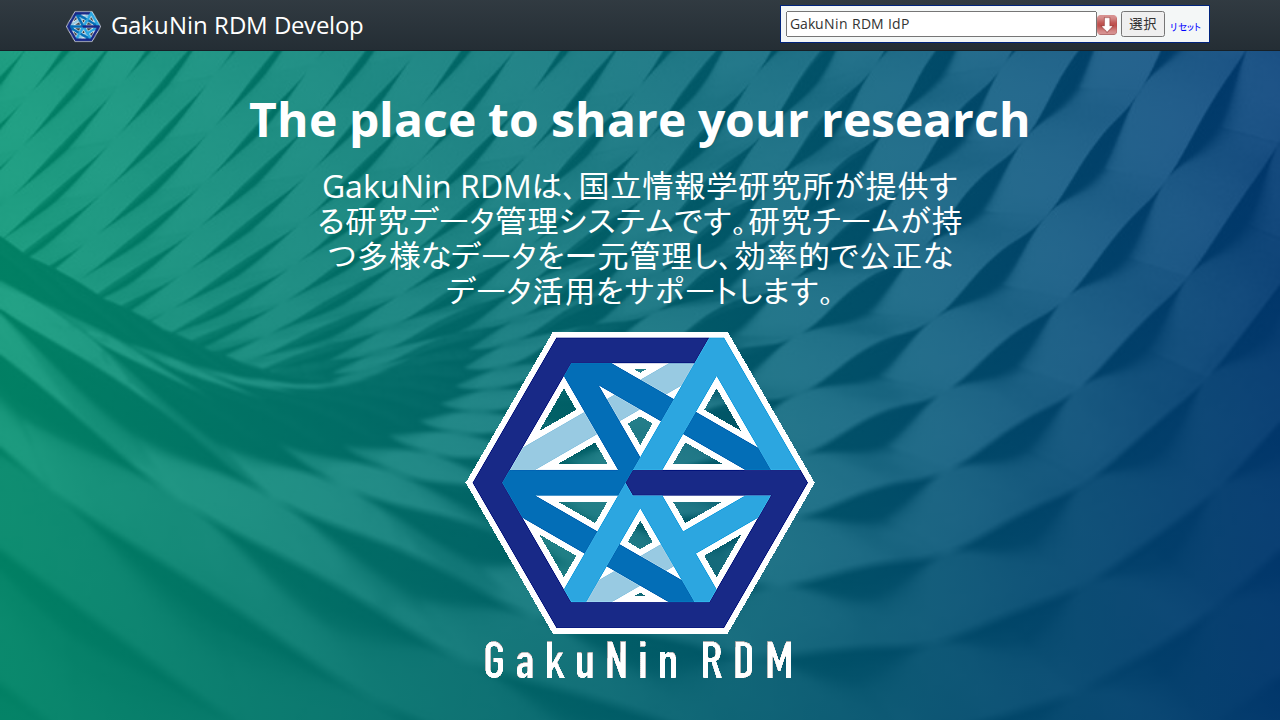

In [60]:
async def _step(page):
    await page.locator(f'//div[@class = "nav-profile-name"]').click()
    await page.get_by_role("link", name=" ログアウト").click()

    # ログアウト成功の確認
    if idp_name_1 == 'FakeCAS':
        # FakeCASの場合はサインインボタンが表示されることを確認
        await expect(page.locator('//button[@data-test-sign-in-button]')).to_be_visible(timeout=transition_timeout)
    elif idp_name_1 is not None:
        # 通常のGakuNin DSの場合はdropdown_imgが表示されることを確認
        await expect(page.locator('//*[@id = "dropdown_img"]')).to_be_visible(timeout=transition_timeout)
    else:
        # CASの場合はログインボタンが表示されることを確認
        await expect(page.locator('//button[text() = "ログイン"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

終了処理を実施。

In [61]:
await finish_pw_context()

In [62]:
!rm -fr {work_dir}